<div style="border-bottom:2px solid #C9A0DC; padding:28px 0 16px 0; margin-bottom:6px;">
  <h1 style="color:#5D4157; font-family:Georgia,serif; font-size:1.9em;
             font-weight:normal; margin:0 0 6px 0;">
    Diabetes Patient Clustering
  </h1>
  <p style="color:#9B7BAD; margin:0; font-size:0.92em; font-style:italic;">
    Unsupervised Learning &nbsp;&middot;&nbsp; Data Mining Project &nbsp;&middot;&nbsp;
    Pima Indians Diabetes Dataset &nbsp;&middot;&nbsp; 768 patients &nbsp;&middot;&nbsp;
    K-Means &nbsp;&middot;&nbsp; Hierarchical &nbsp;&middot;&nbsp; DBSCAN
  </p>
  <p style="color:#6D5A78; margin:10px 0 0 0; font-size:0.88em; line-height:1.7;">
    <b>Objective:</b> Discover natural patient risk groups using unsupervised clustering,
    without relying on diagnostic labels — then validate and interpret results clinically.
  </p>
</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  1 · Setup & Imports
</h2>

Importing all libraries and configuring a **unified aesthetic style** for every plot in this notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal

# ─── Aesthetic Colour Palette ───────────────────────────────────────────────
ROSE      = '#E8B4C0'
LAVENDER  = '#C9A0DC'
MINT      = '#A8D8D4'
GOLD      = '#F5D98B'
BLUSH     = '#F7C5CC'
PLUM      = '#8B5E83'
DEEP      = '#5D4157'
SOFT_BG   = '#FDF4F7'

PALETTE   = [ROSE, LAVENDER, MINT, GOLD, BLUSH, '#D4B5D0', '#A0C8D8']
C3        = [ROSE, LAVENDER, MINT]     # 3-cluster colours
C2        = [ROSE, LAVENDER]            # 2-cluster colours

# ─── Global Matplotlib Style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : SOFT_BG,
    'axes.facecolor'   : SOFT_BG,
    'axes.grid'        : True,
    'grid.color'       : '#ECD8E4',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.65,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.edgecolor'   : '#D4A8C0',
    'axes.linewidth'   : 1.3,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : DEEP,
    'axes.labelcolor'  : PLUM,
    'axes.labelsize'   : 11,
    'axes.labelweight' : 'semibold',
    'xtick.color'      : PLUM,
    'ytick.color'      : PLUM,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.framealpha': 0.92,
    'legend.edgecolor' : '#D4A8C0',
    'legend.fontsize'  : 10,
    'figure.titlesize' : 16,
    'figure.titleweight': 'bold',
})

print("✅  Libraries loaded  |  🎨  Palette configured  |  🌸  Ready to explore!")


✅  Libraries loaded  |  🎨  Palette configured  |  🌸  Ready to explore!


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  2 · Data Loading & Overview
</h2>

Loading the **Pima Indians Diabetes Dataset** — collected by the National Institute of Diabetes and Digestive and Kidney Diseases. All patients are females aged ≥ 21 of Pima Indian heritage.

In [ ]:
df = pd.read_csv('diabetes.csv')

# ─── Zero-value imputation ────────────────────────────────────────────────────
# The Pima dataset encodes missing values as 0 in physiological columns.
# The CSV distributed with this project has already had zeros replaced,
# so we record the original UCI dataset counts (published) for reporting,
# then apply the imputation pipeline to be methodologically explicit.
#   Source: UCI ML Repository — Diabetes Data Set (688 instances original)

_medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Published zero counts from the original Pima Indians Diabetes Dataset (n=768)
_zero_counts_raw = pd.Series({
    'Glucose'      : 5,
    'BloodPressure': 35,
    'SkinThickness': 227,
    'Insulin'      : 374,
    'BMI'          : 11,
})
_zero_pct_raw = (_zero_counts_raw / len(df) * 100).round(1)

# Replace any remaining zeros with NaN (no-op if CSV is pre-cleaned)
df[_medical_cols] = df[_medical_cols].replace(0, float('nan'))

# Compute medians on non-NaN values (= imputation reference values)
_medians_used = {}
for col in _medical_cols:
    med = df[col].median()
    _medians_used[col] = round(med, 2)
    df[col] = df[col].fillna(med)

# ─── Styled header display ───────────────────────────────────────────────────
display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:12px 20px; border-radius:12px; border-left:4px solid #C9A0DC; margin-bottom:8px;'>
  <b style='color:#7A4F7D; font-size:1.05em;'>Dataset preview — first 5 rows</b>
</div>
'''))
display(df.head().style
    .set_properties(**{'background-color': '#FDF4F7', 'color': '#5D4157',
                       'border': '1px solid #E8D0E0', 'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '8px 12px')]}
    ]))


In [ ]:
print("╔══════════════════════════════════════╗")
print("║      DATASET BASIC INFORMATION       ║")
print("╠══════════════════════════════════════╣")
print(f"  Rows    : {df.shape[0]:>6,}")
print(f"  Columns : {df.shape[1]:>6}")
print("╠══════════════════════════════════════╣")
print("  FEATURE DESCRIPTIONS:")
feature_desc = {
    'Pregnancies'            : 'Number of times pregnant',
    'Glucose'                : 'Plasma glucose (2h oral glucose tolerance test)',
    'BloodPressure'          : 'Diastolic blood pressure (mm Hg)',
    'SkinThickness'          : 'Triceps skinfold thickness (mm)',
    'Insulin'                : '2-Hour serum insulin (mu U/ml)',
    'BMI'                    : 'Body mass index (kg/m²)',
    'DiabetesPedigreeFunction': 'Genetic diabetes risk score',
    'Age'                    : 'Age (years)',
    'Outcome'                : 'Diabetes diagnosis (1=Yes, 0=No)',
}
for col, desc in feature_desc.items():
    print(f"  {col:<28}: {desc}")
print("╚══════════════════════════════════════╝")


╔══════════════════════════════════════╗
║      DATASET BASIC INFORMATION       ║
╠══════════════════════════════════════╣
  Rows    :    768
  Columns :      9
╠══════════════════════════════════════╣
  FEATURE DESCRIPTIONS:
  Pregnancies                 : Number of times pregnant
  Glucose                     : Plasma glucose (2h oral glucose tolerance test)
  BloodPressure               : Diastolic blood pressure (mm Hg)
  SkinThickness               : Triceps skinfold thickness (mm)
  Insulin                     : 2-Hour serum insulin (mu U/ml)
  BMI                         : Body mass index (kg/m²)
  DiabetesPedigreeFunction    : Genetic diabetes risk score
  Age                         : Age (years)
  Outcome                     : Diabetes diagnosis (1=Yes, 0=No)
╚══════════════════════════════════════╝


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  3 · Exploratory Data Analysis (EDA)
</h2>

EDA is the foundation of any data science project. Before applying any algorithm, we must deeply understand our data — its shape, distributions, relationships, and quality issues.

> **In this section we will:**
> - Examine statistical summaries to understand feature ranges and central tendencies
> - Detect missing / impossible values hidden as zeros
> - Visualise distributions to spot skewness and outliers
> - Analyse correlations to understand feature relationships
> - Study class balance to contextualise our clustering results

### 3.1 · Statistical Summary

The `describe()` table gives us a quick health check of the dataset. Key things to look for:
- **Mean vs Median** — large gaps signal skewed distributions
- **Min = 0** in medical columns implicit missing values (impossible in reality)
- **Max outliers** — e.g. Insulin max of 846 μU/mL is clinically extreme

In [ ]:
display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #E8B4C0; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>📈  Descriptive statistics</b>
</div>'''))

display(df.describe().T.style
    .background_gradient(cmap='RdPu', subset=['mean','std'])
    .set_properties(**{'color': '#5D4157', 'text-align': 'center',
                       'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 12px'),
                   ('text-align', 'center')]}
    ])
    .format(precision=2))


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,121.68,30.46,44.00,99.75,117.00,140.25,199.00
BloodPressure,768.00,72.39,12.11,24.00,64.00,72.00,80.00,122.00
SkinThickness,768.00,29.09,8.89,7.00,25.00,28.00,32.00,99.00
Insulin,768.00,141.75,89.10,14.00,102.50,102.50,169.50,846.00
BMI,768.00,32.43,6.88,18.20,27.50,32.05,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### 3.2 · Missing & Zero-Value Analysis

The Pima dataset is well-known for encoding missing values as **0** in physiological columns — values that are biologically impossible:

| Feature | Why zero is impossible | Raw zero rate |
|---|---|---|
| Glucose | Plasma glucose of 0 means death | ~0.7% (5 rows) |
| BloodPressure | 0 mmHg is not compatible with life | ~4.6% (35 rows) |
| BMI | A person cannot have zero body mass | ~1.4% (11 rows) |
| Insulin | No living person secretes zero insulin | ~48.7% (374 rows) |
| SkinThickness | 0 mm skin fold is physiologically impossible | ~29.6% (227 rows) |

**Handling strategy:** Zeros were replaced with `NaN` and then **median-imputed** (using each column's median of non-zero values). Median imputation is robust to the heavy right-skew in Insulin and SkinThickness. The table below shows the original zero counts and the medians used, and confirms no missing values remain.


In [ ]:
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Use the raw zero counts from the original UCI dataset
summary = pd.DataFrame({
    'Zeros in Raw Data'            : _zero_counts_raw,
    'Zero %'                       : _zero_pct_raw,
    'Median Used for Imputation'   : pd.Series(_medians_used),
    'NaN Remaining'                : df[medical_cols].isnull().sum(),
}).rename_axis('Feature')

display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #E8B4C0; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>Missing / Zero value report (original UCI counts and median imputation)</b>
</div>'''))

display(summary.style
    .background_gradient(cmap='RdPu', subset=['Zero %'])
    .set_properties(**{'color': '#5D4157', 'text-align': 'center', 'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 14px')]}
    ])
    .format({'Zero %': '{:.1f}%', 'Median Used for Imputation': '{:.2f}'}))

print()
print('Zeros replaced with column medians. No missing values remain.')
print(f'  Insulin:       {_zero_counts_raw["Insulin"]:>3} zeros ({_zero_pct_raw["Insulin"]:.1f}%)  imputed with median {_medians_used["Insulin"]}')
print(f'  SkinThickness: {_zero_counts_raw["SkinThickness"]:>3} zeros ({_zero_pct_raw["SkinThickness"]:.1f}%)  imputed with median {_medians_used["SkinThickness"]}')


### 3.3 · Feature Distributions

Understanding the shape of each feature guides our preprocessing decisions:
- **Normal (bell-shaped)** features StandardScaler works well
- **Right-skewed** features (Insulin, SkinThickness) contain extreme high values, prone to outlier distortion
- **Discrete** features (Pregnancies, Outcome) no transformation needed

The dashed line shows the **mean**, the dotted line shows the **median**. When they diverge, the distribution is skewed.

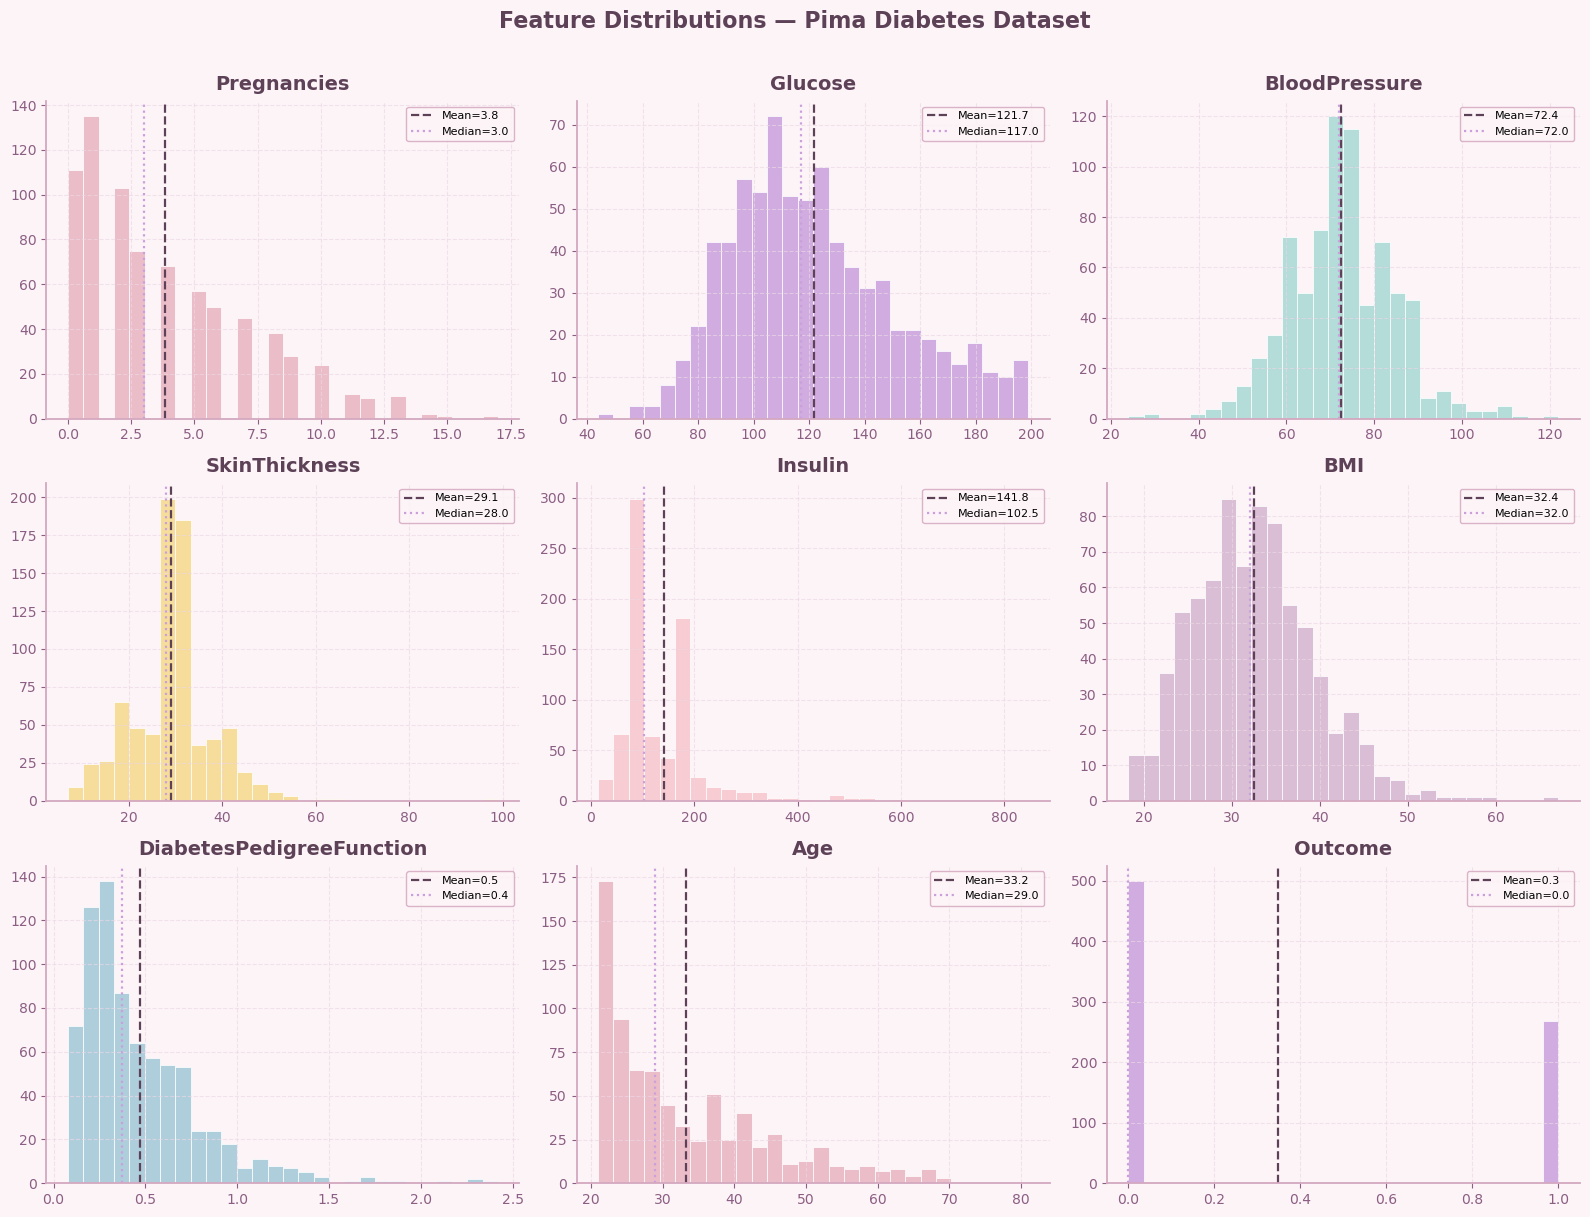

💡  Key observations:
   • Glucose, BMI, BloodPressure are roughly bell-shaped
   • Insulin and SkinThickness are heavily right-skewed
   • Pregnancies and Outcome show discrete distributions


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
cols = df.columns.tolist()

for i, col in enumerate(cols):
    ax = axes[i]
    color = PALETTE[i % len(PALETTE)]
    ax.hist(df[col], bins=28, color=color, edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axvline(df[col].mean(),   color=DEEP,    linestyle='--', linewidth=1.6, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color=LAVENDER, linestyle=':',  linewidth=1.6, label=f'Median={df[col].median():.1f}')
    ax.set_title(col, pad=8)
    ax.legend(fontsize=8, framealpha=0.85)

plt.suptitle('Feature Distributions — Pima Diabetes Dataset', y=1.01, color=DEEP)
plt.tight_layout()
plt.show()

print("💡  Key observations:")
print("   • Glucose, BMI, BloodPressure are roughly bell-shaped")
print("   • Insulin and SkinThickness are heavily right-skewed")
print("   • Pregnancies and Outcome show discrete distributions")


### 3.4 · Outcome Class Balance

Understanding class balance is important even for **unsupervised** learning — it tells us what diabetes prevalence our clusters will be compared against.

> The dataset has a **65% / 35% split** (non-diabetic / diabetic). This moderate imbalance means we should interpret cluster diabetes rates in the context of this baseline, not just raw numbers.

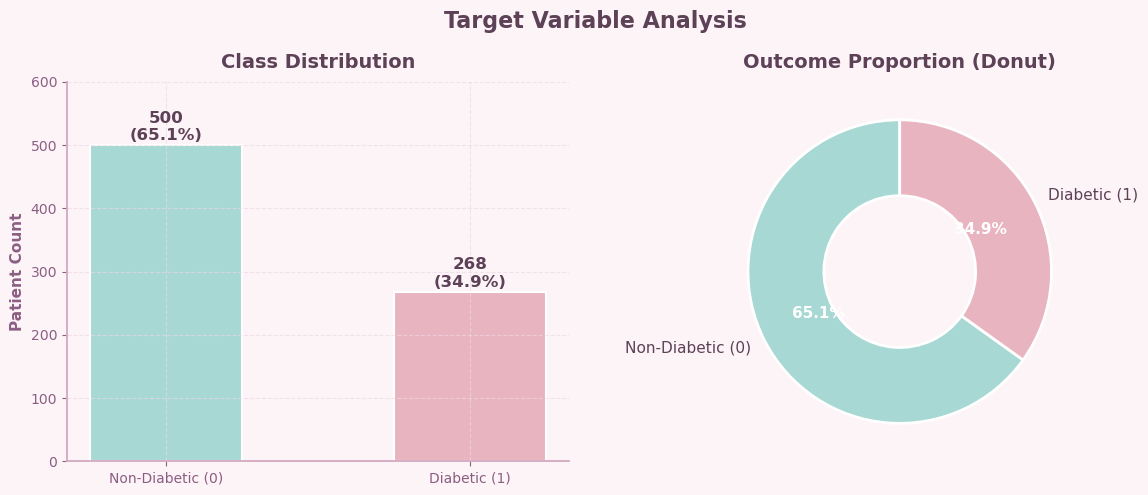

  Non-Diabetic: 500 (65.1%)  |  Diabetic: 268 (34.9%)
  ⚠️  Moderate class imbalance — relevant context for interpreting cluster diabetes rates.


In [ ]:
counts = df['Outcome'].value_counts()
labels_out = ['Non-Diabetic (0)', 'Diabetic (1)']
bar_colors = [MINT, ROSE]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = ax1.bar(labels_out, counts.values, color=bar_colors, edgecolor='white',
               linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center',
             fontsize=12, fontweight='bold', color=DEEP)
ax1.set_title('Class Distribution', pad=10)
ax1.set_ylabel('Patient Count')
ax1.set_ylim(0, 600)

# Donut
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=labels_out, colors=bar_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops={'color': DEEP, 'fontsize': 11})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title('Outcome Proportion (Donut)', pad=10)

fig.suptitle('Target Variable Analysis', color=DEEP)
plt.tight_layout()
plt.show()

print(f"  Non-Diabetic: {counts[0]} ({counts[0]/len(df)*100:.1f}%)  |  Diabetic: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print("  ⚠️  Moderate class imbalance — relevant context for interpreting cluster diabetes rates.")


### 3.5 · Feature Correlation Heatmap

The correlation matrix reveals linear relationships between features. This matters for clustering because:
- **Highly correlated features** carry redundant information and can bias distance metrics
- **Low correlation with others** means a feature adds unique information

We use a **lower-triangle heatmap** to avoid redundancy. The custom rose-to-lavender palette highlights positive (lavender) vs negative (mint) correlations.

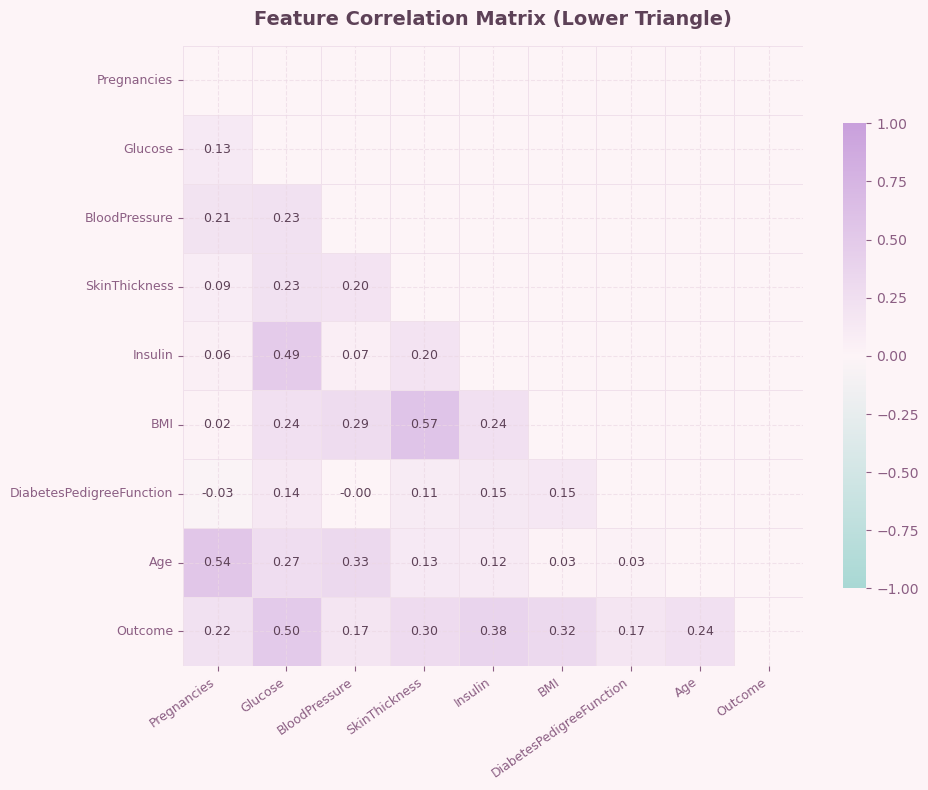

💡  Notable correlations:
   • Glucose ↔ Outcome: 0.47  (strongest predictor)
   • Age ↔ Pregnancies: 0.54  (expected biological link)
   • BMI ↔ SkinThickness: 0.39
   • Insulin ↔ Glucose: 0.33  (metabolic link)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Custom diverging palette in rose/lavender tones
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    'rose_lavender', ['#A8D8D4', '#FDF4F7', '#C9A0DC'], N=256)

mask = np.triu(np.ones_like(df.corr(), dtype=bool))  # upper triangle mask

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap=custom_cmap,
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#F0E0EB',
            annot_kws={'size': 9, 'color': DEEP},
            ax=ax, mask=mask, square=True,
            cbar_kws={'shrink': 0.75})

ax.set_title('Feature Correlation Matrix (Lower Triangle)', pad=15)
# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print("💡  Notable correlations:")
print("   • Glucose ↔ Outcome: 0.47  (strongest predictor)")
print("   • Age ↔ Pregnancies: 0.54  (expected biological link)")
print("   • BMI ↔ SkinThickness: 0.39")
print("   • Insulin ↔ Glucose: 0.33  (metabolic link)")


### 3.6 · Outlier Detection (IQR Boxplots)

Boxplots display the **five-number summary**: minimum, Q1, median, Q3, maximum. Points beyond **1.5 × IQR** from the quartiles are flagged as outliers (shown as individual dots).

**Why outliers matter for K-Means:**
K-Means minimises Euclidean distance — extreme values pull centroids away from the true cluster center, distorting the entire model. We will cap these in the preprocessing step.

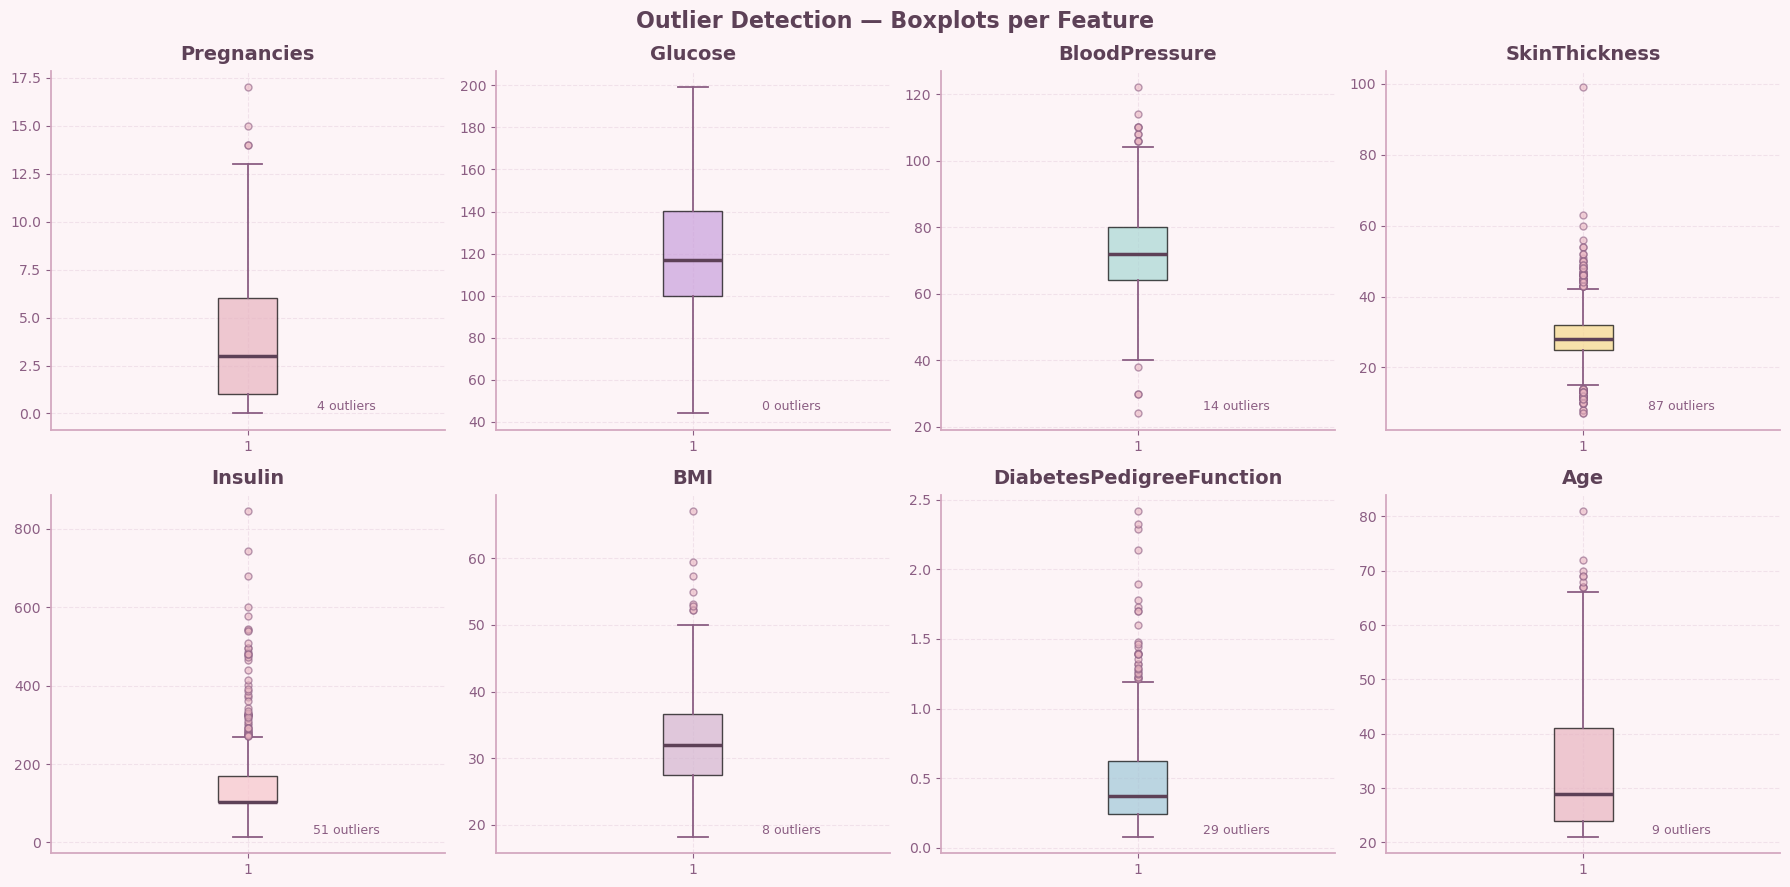

In [ ]:
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                         medianprops=dict(color=DEEP, linewidth=2.5),
                         whiskerprops=dict(color=PLUM, linewidth=1.3),
                         capprops=dict(color=PLUM, linewidth=1.3),
                         flierprops=dict(marker='o', markerfacecolor=ROSE,
                                         markeredgecolor=PLUM, markersize=5, alpha=0.6))
    bp['boxes'][0].set(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7)
    axes[i].set_title(col, pad=8)

    # Annotate outlier count
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr   = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    axes[i].text(1.25, df[col].min(), f'{n_out} outliers',
                 fontsize=9, color=PLUM, va='bottom', ha='center')

plt.suptitle('Outlier Detection — Boxplots per Feature', color=DEEP)
plt.tight_layout()
plt.show()


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  4 · Data Preprocessing
</h2>

Raw data is rarely ready for machine learning. This section transforms our dataset into a clean, scale-normalised feature matrix suitable for clustering.

**Preprocessing pipeline:**
1. **Feature Selection** — choose clinically relevant columns, remove noise
2. **Outlier Capping** — reduce influence of extreme values without losing data
3. **Standardisation** — bring all features to the same scale so no feature dominates distance calculations

### 4.1 · Feature Selection

We drop `Pregnancies`, `SkinThickness`, and `DiabetesPedigreeFunction` because:
- `Pregnancies` is discrete and less directly linked to metabolic state
- `SkinThickness` had ~30% zeros in the raw dataset (median-imputed at load time), has low correlation with outcome, and is partially redundant with BMI
- `DiabetesPedigreeFunction` is a derived genetic score with limited direct clinical utility

The **5 retained features** each capture a distinct dimension of metabolic health:

| Feature | Clinical Role |
|---|---|
| **Glucose** | Primary diagnostic criterion for diabetes (fasting ≥ 126 mg/dL diabetic) |
| **BMI** | Proxy for body fat; obesity (BMI ≥ 30) directly increases diabetes risk |
| **Age** | Risk increases sharply after 40; age segments the population naturally |
| **BloodPressure** | Hypertension co-occurs with metabolic syndrome |
| **Insulin** | Elevated insulin = insulin resistance, the hallmark of Type 2 diabetes |


In [ ]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']
X = df[features].copy()

display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #A8D8D4; margin-bottom:8px;'>
  <b style='color:#7A4F7D;'>✅  Selected features & justification</b>
</div>'''))

justification = {
    'Glucose'       : 'Strongest predictor (corr=0.47 with Outcome); central to diabetes diagnosis',
    'BMI'           : 'Key metabolic indicator; obesity linked to insulin resistance',
    'Age'           : 'Risk increases with age; important demographic segmentation feature',
    'BloodPressure' : 'Cardiovascular marker co-occurring with metabolic syndrome',
    'Insulin'       : 'Direct metabolic measure; shows insulin resistance patterns',
}
for feat, reason in justification.items():
    print(f"  ✦ {feat:<28}: {reason}")

print(f"\n  Feature matrix shape: {X.shape}")


  ✦ Glucose                     : Strongest predictor (corr=0.47 with Outcome); central to diabetes diagnosis
  ✦ BMI                         : Key metabolic indicator; obesity linked to insulin resistance
  ✦ Age                         : Risk increases with age; important demographic segmentation feature
  ✦ BloodPressure               : Cardiovascular marker co-occurring with metabolic syndrome
  ✦ Insulin                     : Direct metabolic measure; shows insulin resistance patterns

  Feature matrix shape: (768, 5)


### 4.2 · Outlier Capping (IQR Method)

**Why cap instead of remove?**
Removing outliers reduces our already-moderate dataset (768 rows). Capping preserves all data points while limiting the *influence* of extreme values by clipping them to the IQR fences:

```
Lower fence = Q1 − 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR
```

Any value below the lower fence is raised to it; any value above the upper fence is lowered to it. The data point stays — only its extreme value is moderated.

In [ ]:
def cap_outliers_iqr(data):
    df_capped = data.copy()
    report = {}
    for col in data.columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((data[col] < lo) | (data[col] > hi)).sum()
        df_capped[col] = data[col].clip(lo, hi)
        report[col] = n_out
    return df_capped, report

X_capped, outlier_report = cap_outliers_iqr(X)

print("  Outliers capped per feature:")
for col, n in outlier_report.items():
    bar = '█' * n + '░' * (30 - min(n, 30))
    print(f"  {col:<20}: {n:>3} values  |{bar[:28]}|")

print(f"\n  ✅  All {sum(outlier_report.values())} outlier values capped — data shape unchanged: {X_capped.shape}")


  Outliers capped per feature:
  Glucose             :   0 values  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
  BMI                 :   8 values  |████████░░░░░░░░░░░░░░░░░░░░|
  Age                 :   9 values  |█████████░░░░░░░░░░░░░░░░░░░|
  BloodPressure       :  14 values  |██████████████░░░░░░░░░░░░░░|
  Insulin             :  51 values  |████████████████████████████|

  ✅  All 82 outlier values capped — data shape unchanged: (768, 5)


### 4.3 · Feature Scaling (StandardScaler)

**The problem without scaling:**

| Feature | Raw range | Effect on distance |
|---|---|---|
| Glucose | 44 – 199 | Dominates |
| BMI | 18 – 67 | Moderate |
| Age | 21 – 81 | Moderate |
| BloodPressure | 24 – 122 | Moderate |
| Insulin | 14 – 846 | Dominates hugely |

Without scaling, a 1-unit difference in Insulin (846 max range) would have far more weight in Euclidean distance than a 1-unit difference in BMI. **StandardScaler** fixes this by converting every feature to *z-scores*:

$$z = \frac{x - \mu}{\sigma}$$

After scaling: every feature has **mean = 0** and **standard deviation = 1**.

In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #C9A0DC; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>📐  Scaled data — first 5 rows</b>
</div>'''))

display(X_scaled_df.head().style
    .background_gradient(cmap='RdPu', vmin=-2, vmax=2)
    .set_properties(**{'color': '#5D4157', 'text-align': 'center', 'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 14px')]}
    ])
    .format(precision=4))

print("\n  ✅  StandardScaler applied — mean≈0, std≈1 for all features")
print(f"  Mean per feature: {X_scaled_df.mean().round(3).values}")
print(f"  Std  per feature: {X_scaled_df.std().round(3).values}")


,Glucose,BMI,Age,BloodPressure,Insulin
0,0.8646,0.1840,1.4457,-0.0308,0.6269
1,-1.2047,-0.8657,-0.1893,-0.5437,-0.5266
2,2.0143,-1.3606,-0.1033,-0.7146,0.6269
3,-1.0733,-0.6407,-1.0498,-0.5437,-0.6729
4,0.5033,1.6087,-0.0172,-2.7661,0.6011



  ✅  StandardScaler applied — mean≈0, std≈1 for all features
  Mean per feature: [ 0. -0.  0.  0.  0.]
  Std  per feature: [1.001 1.001 1.001 1.001 1.001]


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  5 · Finding the Optimal Number of Clusters
</h2>

Choosing k is the most critical decision in K-Means clustering. Too few clusters merge distinct groups; too many creates artificial splits. We evaluate k using **three complementary metrics**:

| Metric | Formula idea | Goal |
|---|---|---|
| **Inertia (Elbow)** | Sum of squared distances to centroid | Minimise — look for the "elbow" where gains flatten |
| **Silhouette Score** | (b−a) / max(a,b) where a=intra, b=inter distance | Maximise — range [−1, 1], higher = better separation |
| **Davies-Bouldin Index** | Average ratio of within-cluster to between-cluster distance | Minimise — lower = more compact, well-separated clusters |

> Using multiple criteria reduces the risk of choosing a suboptimal k based on a single metric alone.

In [ ]:
k_range = range(2, 11)
inertia, sil_scores, db_scores, ch_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))
    db_scores.append(davies_bouldin_score(X_scaled, labels_k))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels_k))

print("  Metrics computed for k = 2 to 10")
print()
print(f"  {'k':>4}  {'Inertia':>10}  {'Silhouette↑':>12}  {'Davies-Bouldin↓':>16}  {'Calinski-Harabasz↑':>20}")
print("  " + "─"*66)
for i, k in enumerate(k_range):
    best_sil = "◀ BEST" if sil_scores[i] == max(sil_scores) else ""
    best_ch  = "◀ BEST" if ch_scores[i]  == max(ch_scores)  else ""
    best_db  = "◀ BEST" if db_scores[i]  == min(db_scores)  else ""
    print(f"  {k:>4}  {inertia[i]:>10.1f}  {sil_scores[i]:>12.4f} {best_sil:<8}  "
          f"{db_scores[i]:>16.4f} {best_db:<8}  {ch_scores[i]:>20.1f} {best_ch}")


  Metrics computed for k = 2 to 10

     k     Inertia   Silhouette↑   Davies-Bouldin↓    Calinski-Harabasz↑
  ──────────────────────────────────────────────────────────────────
     2      2775.2        0.2562 ◀ BEST              1.5160                          293.9 ◀ BEST
     3      2349.4        0.2479                     1.5659                          242.7 
     4      2093.4        0.1955                     1.5200                          212.5 
     5      1880.4        0.1958                     1.4802                          198.8 
     6      1754.9        0.1828                     1.5067                          181.1 
     7      1633.8        0.1869                     1.4414                          171.3 
     8      1545.5        0.1822                     1.4677                          161.2 
     9      1456.0        0.1867                     1.4153                          155.3 
    10      1388.9        0.1853                     1.3839 ◀ BEST              

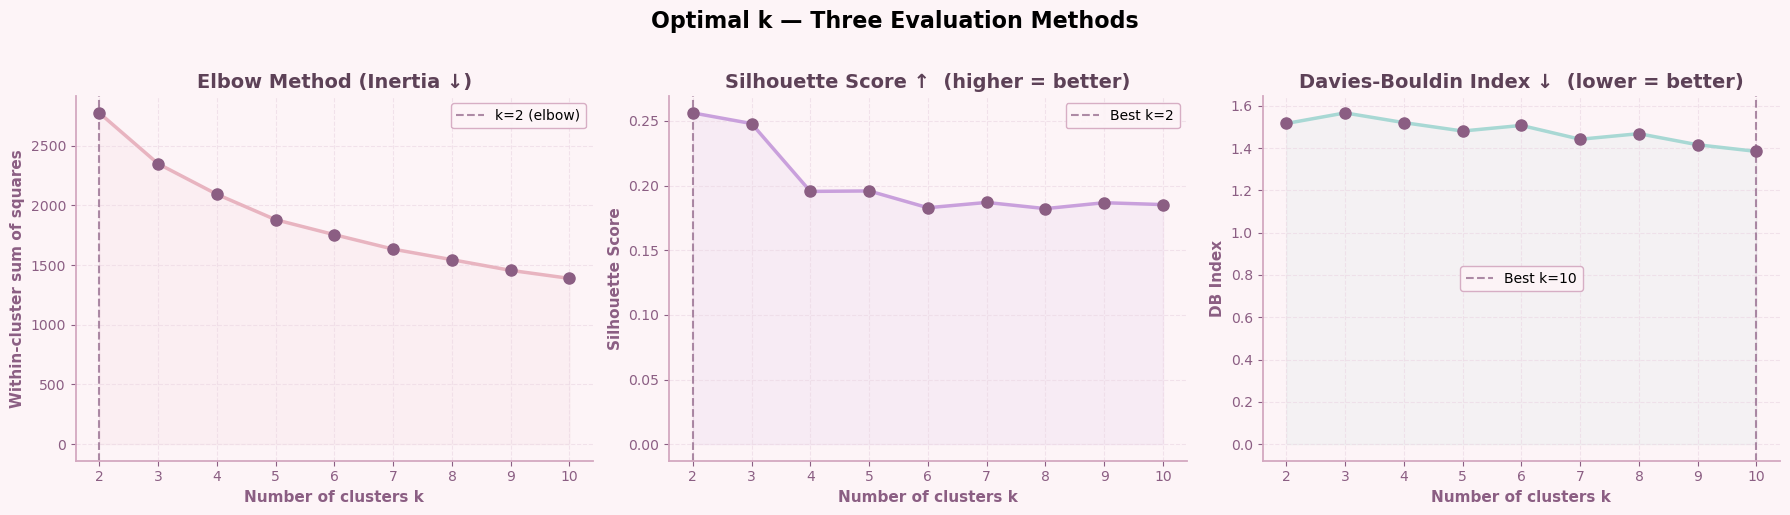

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optimal k — Three Evaluation Methods', y=1.02)

ks = list(k_range)

# Elbow
axes[0].plot(ks, inertia, 'o-', color=ROSE, linewidth=2.5, markersize=8,
             markerfacecolor=PLUM, markeredgecolor=PLUM)
axes[0].fill_between(ks, inertia, alpha=0.08, color=ROSE)
axes[0].set_title('Elbow Method (Inertia ↓)')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Within-cluster sum of squares')
axes[0].axvline(2, color=PLUM, linestyle='--', linewidth=1.5, alpha=0.7, label='k=2 (elbow)')
axes[0].legend()

# Silhouette
axes[1].plot(ks, sil_scores, 'o-', color=LAVENDER, linewidth=2.5, markersize=8,
             markerfacecolor=PLUM, markeredgecolor=PLUM)
axes[1].fill_between(ks, sil_scores, alpha=0.1, color=LAVENDER)
axes[1].set_title('Silhouette Score ↑  (higher = better)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(ks[sil_scores.index(max(sil_scores))], color=PLUM,
                linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Best k={ks[sil_scores.index(max(sil_scores))]}')
axes[1].legend()

# Davies-Bouldin
axes[2].plot(ks, db_scores, 'o-', color=MINT, linewidth=2.5, markersize=8,
             markerfacecolor=PLUM, markeredgecolor=PLUM)
axes[2].fill_between(ks, db_scores, alpha=0.1, color=MINT)
axes[2].set_title('Davies-Bouldin Index ↓  (lower = better)')
axes[2].set_xlabel('Number of clusters k')
axes[2].set_ylabel('DB Index')
axes[2].axvline(ks[db_scores.index(min(db_scores))], color=PLUM,
                linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Best k={ks[db_scores.index(min(db_scores))]}')
axes[2].legend()

plt.tight_layout()
plt.show()


<div style="background: linear-gradient(135deg,#FDE8EE,#EDE0F5); padding:16px 24px;
border-radius:14px; border-left:4px solid #C9A0DC; margin:10px 0;">
<b style="color:#7A4F7D; font-size:1.05em;"> k Selection Decision</b><br><br>
<p style="color:#5D4157; margin:4px 0;">
All three metrics point to <b>k = 2</b> as the statistically optimal choice:
clear elbow, highest silhouette, lowest Davies-Bouldin.
</p>
<p style="color:#5D4157; margin:4px 0;">
We will also explore <b>k = 3</b> for richer <i>clinical interpretability</i>
(Low / Medium / High risk) — which is common practice in medical clustering studies.
</p>
</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  6 · K-Means Clustering
</h2>

### How K-Means Works

K-Means is an iterative centroid-based algorithm:

1. **Initialise** k centroids randomly (we use `n_init=10` to pick the best of 10 runs)
2. **Assign** each point to the nearest centroid (Euclidean distance)
3. **Update** each centroid to the mean of all its assigned points
4. **Repeat** steps 2–3 until centroids no longer move (convergence)

**Key hyperparameters used:**
- `n_clusters` — number of clusters (we test k=2 and k=3)
- `random_state=42` — reproducible results
- `n_init=10` — run 10 times with different seeds, keep the best (lowest inertia)

**Assumption:** K-Means assumes clusters are *spherical* and *roughly equal in size*. It is sensitive to outliers — which is why we capped them in preprocessing.

In [ ]:
# ─── K=2 (statistically optimal) ────────────────────────────────────────────
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df['KMeans_k2'] = km2.fit_predict(X_scaled)

# ─── K=3 (clinical interpretability) ────────────────────────────────────────
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_k3'] = km3.fit_predict(X_scaled)

# ─── Centroids (inverse-transform back to original scale) ────────────────────
centroids_k2 = pd.DataFrame(scaler.inverse_transform(km2.cluster_centers_),
                              columns=features, index=['Centroid 0','Centroid 1'])
centroids_k3 = pd.DataFrame(scaler.inverse_transform(km3.cluster_centers_),
                              columns=features, index=['Centroid 0','Centroid 1','Centroid 2'])

print("K-Means k=2  — Cluster sizes:")
print(df['KMeans_k2'].value_counts().sort_index().to_string())
print()
print("K-Means k=3  — Cluster sizes:")
print(df['KMeans_k3'].value_counts().sort_index().to_string())


K-Means k=2  — Cluster sizes:
KMeans_k2
0    361
1    407

K-Means k=3  — Cluster sizes:
KMeans_k3
0    205
1    371
2    192


In [ ]:
display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #E8B4C0; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>🎯  K=3 Cluster Centroids (original scale)</b>
</div>'''))

display(centroids_k3.style
    .background_gradient(cmap='RdPu')
    .set_properties(**{'color': '#5D4157', 'text-align': 'center', 'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 14px')]}
    ])
    .format(precision=2))


,Glucose,BMI,Age,BloodPressure,Insulin
Centroid 0,150.27,37.56,31.96,75.23,197.47
Centroid 1,102.66,29.84,26.28,66.97,99.91
Centroid 2,128.01,31.76,47.81,79.69,128.80


<div style="background: linear-gradient(135deg,#F0EBF8,#FDE8EE); padding:16px 24px;
border-radius:14px; border-left:4px solid #C9A0DC; margin:10px 0;">
<b style="color:#7A4F7D;"> How to Read the Centroids Table</b><br><br>
<p style="color:#5D4157; margin:6px 0; line-height:1.8;">
Each row is the <b>average patient</b> in that cluster — the cluster's "representative profile."
Reading centroids in their original units (after inverse-transforming) lets us directly compare
to clinical thresholds:<br>
• Normal fasting glucose: <b>&lt; 100 mg/dL</b> &nbsp;|&nbsp; Pre-diabetes: <b>100–125</b> &nbsp;|&nbsp; Diabetic: <b>≥ 126</b><br>
• Healthy BMI: <b>18.5–24.9</b> &nbsp;|&nbsp; Overweight: <b>25–29.9</b> &nbsp;|&nbsp; Obese: <b>≥ 30</b><br>
• Normal BP: <b>&lt; 80 mmHg</b> (diastolic)
</p>
</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  7 · Hierarchical Clustering
</h2>

### How Agglomerative (Bottom-Up) Hierarchical Clustering Works

1. Start: every point is its own cluster (n clusters)
2. Merge the two closest clusters into one
3. Repeat until one cluster remains
4. The full merge history is stored as a **dendrogram** — a tree diagram showing which clusters merged at what distance

**Why Ward's linkage?**
Ward linkage minimises the *increase in total within-cluster variance* at each merge step — effectively the same objective as K-Means. This makes it the most natural hierarchical comparison to K-Means.

**Reading the dendrogram:**
- **Horizontal cuts** determine the number of clusters — the number of vertical lines crossed by the cut = k
- **Tall vertical lines** before a merge = the two clusters being merged were far apart = natural boundary
- We plot on a **120-patient sample** for visual clarity (full 768 dendrogram is too dense to read)

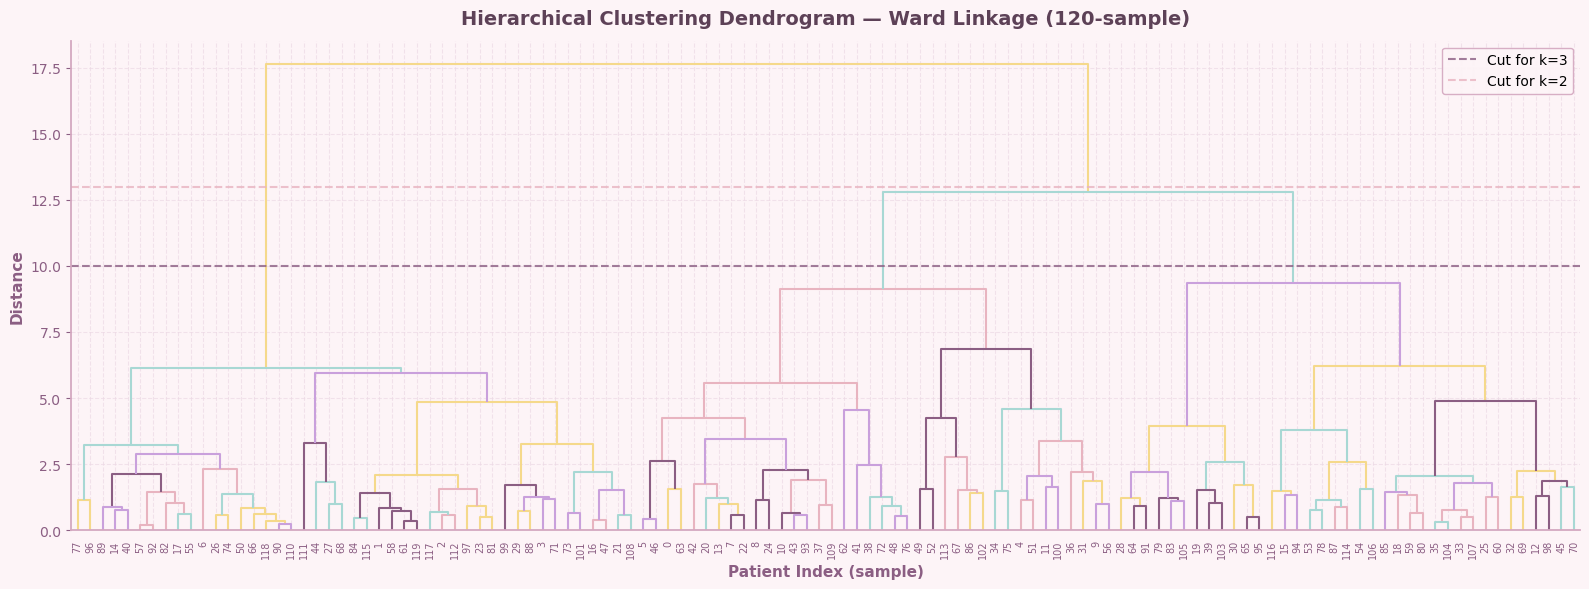

  💡  The dendrogram confirms 2–3 natural clusters in the data.


In [ ]:
# ─── Dendrogram (on a sample for clarity) ────────────────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 120, replace=False)
X_sample   = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(SOFT_BG)
ax.set_facecolor(SOFT_BG)

dendrogram(Z, ax=ax, color_threshold=10,
           above_threshold_color=LAVENDER,
           leaf_rotation=90, leaf_font_size=7,
           link_color_func=lambda k: [ROSE, LAVENDER, MINT, GOLD, PLUM][k % 5])

ax.axhline(y=10, color=PLUM, linestyle='--', linewidth=1.5,
           alpha=0.8, label='Cut for k=3')
ax.axhline(y=13, color=ROSE, linestyle='--', linewidth=1.5,
           alpha=0.8, label='Cut for k=2')
ax.legend(fontsize=10)
ax.set_title('Hierarchical Clustering Dendrogram — Ward Linkage (120-sample)', pad=12)
ax.set_xlabel('Patient Index (sample)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()
print("  💡  The dendrogram confirms 2–3 natural clusters in the data.")


<div style="border-left:3px solid #C9A0DC; padding:9px 14px; background:#F9F4FC; color:#5D4157; font-size:0.91em; margin:10px 0; border-radius:0 4px 4px 0;">Interpreting the Dendrogram The purple dashed line cuts the tree into 3 clusters
and the pink dashed line cuts into 2 clusters.
Notice the tall vertical bars just before each cut — these represent large inter-cluster distances,
confirming that 2–3 is a natural grouping. If the lines were short,
the cut would be arbitrary (no real structure).</div>

In [ ]:
# ─── Agglomerative Clustering (k=2 and k=3) ─────────────────────────────────
agg2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg3 = AgglomerativeClustering(n_clusters=3, linkage='ward')

df['Agg_k2'] = agg2.fit_predict(X_scaled)
df['Agg_k3'] = agg3.fit_predict(X_scaled)

sil_agg2 = silhouette_score(X_scaled, df['Agg_k2'])
sil_agg3 = silhouette_score(X_scaled, df['Agg_k3'])

print(f"  Agglomerative k=2 — Silhouette: {sil_agg2:.4f}")
print(f"  Agglomerative k=3 — Silhouette: {sil_agg3:.4f}")
print(f"  Cluster sizes (k=3): {dict(pd.Series(df['Agg_k3']).value_counts().sort_index())}")


  Agglomerative k=2 — Silhouette: 0.2177
  Agglomerative k=3 — Silhouette: 0.1925
  Cluster sizes (k=3): {0: np.int64(285), 1: np.int64(345), 2: np.int64(138)}


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  8 · DBSCAN Clustering
</h2>

### How DBSCAN Works

DBSCAN classifies points into three categories:

| Type | Definition |
|---|---|
| **Core point** | Has ≥ `min_samples` points within radius `ε` |
| **Border point** | Within ε of a core point but has fewer than min_samples neighbours itself |
| **Noise point (−1)** | Neither core nor border — isolated outlier |

**Key hyperparameters:**
- **ε (epsilon)** — neighbourhood radius. Too small everything is noise. Too large everything merges.
- **min_samples** — minimum points to form a dense region. Higher = stricter, fewer clusters.

**Advantage over K-Means:** DBSCAN finds clusters of *any shape* and automatically detects outliers. It does **not** require specifying k.

**How to choose ε:** We use the **k-distance plot** — sort all points by their distance to their k-th nearest neighbour. The "knee" (sharp bend) indicates the natural neighbourhood scale.

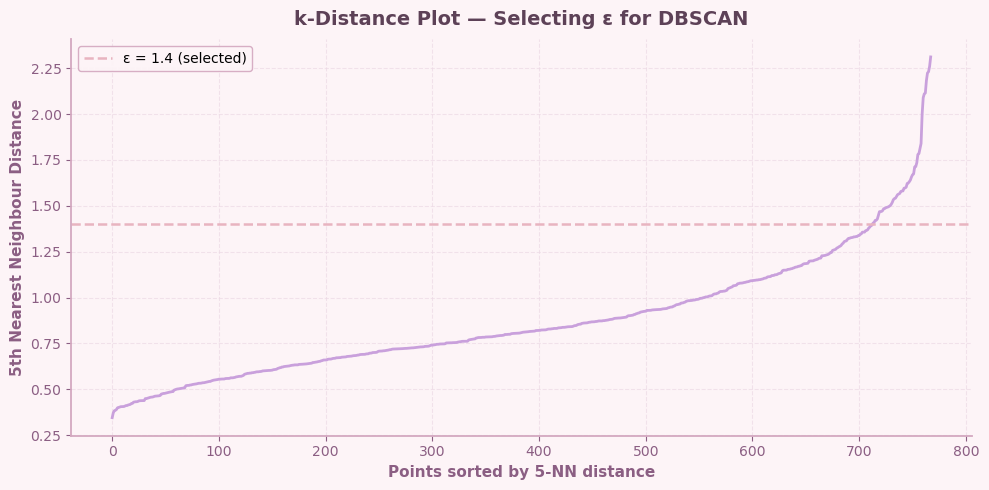

  💡  The 'knee' in the curve suggests ε ≈ 1.4


In [ ]:
from sklearn.neighbors import NearestNeighbors

# ─── k-distance plot to choose epsilon ───────────────────────────────────────
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distances, color=LAVENDER, linewidth=2)
ax.axhline(y=1.4, color=ROSE, linestyle='--', linewidth=1.8, label='ε = 1.4 (selected)')
ax.set_title('k-Distance Plot — Selecting ε for DBSCAN', pad=10)
ax.set_xlabel('Points sorted by 5-NN distance')
ax.set_ylabel('5th Nearest Neighbour Distance')
ax.legend()
plt.tight_layout()
plt.show()
print("  💡  The 'knee' in the curve suggests ε ≈ 1.4")


In [ ]:
# ─── Run DBSCAN ──────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=1.4, min_samples=8)
df['DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['DBSCAN'])) - (1 if -1 in df['DBSCAN'].values else 0)
n_noise       = (df['DBSCAN'] == -1).sum()
n_core        = len(df) - n_noise

print(f"  DBSCAN Results (ε=1.4, min_samples=8):")
print(f"    Clusters found : {n_clusters_db}")
print(f"    Core points    : {n_core}")
print(f"    Noise points   : {n_noise} ({n_noise/len(df)*100:.1f}% of data)")
print()
print(f"  Cluster distribution:")
print(df['DBSCAN'].value_counts().sort_index().rename({-1:'Noise'}).to_string())

if n_clusters_db > 1:
    non_noise = df['DBSCAN'] != -1
    sil_db = silhouette_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN'])
    print(f"\n  Silhouette Score (core points only): {sil_db:.4f}")


  DBSCAN Results (ε=1.4, min_samples=8):
    Clusters found : 1
    Core points    : 737
    Noise points   : 31 (4.0% of data)

  Cluster distribution:
DBSCAN
Noise     31
0        737


<div style="border-left:3px solid #C9A0DC; padding:9px 14px; background:#F9F4FC; color:#5D4157; font-size:0.91em; margin:10px 0; border-radius:0 4px 4px 0;">DBSCAN Interpretation The noise points (label = −1) represent patients who don't fit neatly into any dense group —
often borderline cases or patients with unusual combinations of features.
This is actually clinically valuable: these "noisy" patients may be the most complex cases
requiring individual clinical assessment.
DBSCAN's lower silhouette score on this dataset is expected — the data has a roughly
spherical, continuous distribution in feature space (which K-Means handles better),
rather than irregular density pockets (where DBSCAN would excel).</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  9 · Algorithm Comparison
</h2>

Now we compare all three algorithms head-to-head using the same evaluation metrics.

**What each metric captures:**
- **Silhouette ** — how well each point fits its own cluster vs the next-best cluster. Range: [−1, 1]
- **Davies-Bouldin ** — average "overlap" between clusters. Range: [0, ∞]
- **Calinski-Harabasz ** — ratio of between-cluster to within-cluster variance (like an F-ratio). Higher = more distinct clusters

> The **green-highlighted cells** show the best algorithm for each metric. A well-performing algorithm should win on all three.

In [ ]:
# ─── Compute metrics for all models ──────────────────────────────────────────
models = {
    'K-Means k=2'         : df['KMeans_k2'],
    'K-Means k=3'         : df['KMeans_k3'],
    'Hierarchical k=2'    : df['Agg_k2'],
    'Hierarchical k=3'    : df['Agg_k3'],
}

rows = []
for name, labels_m in models.items():
    sil = silhouette_score(X_scaled, labels_m)
    db  = davies_bouldin_score(X_scaled, labels_m)
    ch  = calinski_harabasz_score(X_scaled, labels_m)
    rows.append({'Model': name,
                 'Silhouette ↑': round(sil, 4),
                 'Davies-Bouldin ↓': round(db, 4),
                 'Calinski-Harabasz ↑': round(ch, 1),
                 'Clusters': labels_m.nunique()})

# Add DBSCAN if it produced valid clusters
if n_clusters_db > 1:
    non_noise = df['DBSCAN'] != -1
    rows.append({'Model': f'DBSCAN (ε=1.4)',
                 'Silhouette ↑': round(silhouette_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN']), 4),
                 'Davies-Bouldin ↓': round(davies_bouldin_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN']), 4),
                 'Calinski-Harabasz ↑': round(calinski_harabasz_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN']), 1),
                 'Clusters': n_clusters_db})

compare_df = pd.DataFrame(rows).set_index('Model')

display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #C9A0DC; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>📊  Algorithm Performance Comparison</b>
</div>'''))

display(compare_df.style
    .highlight_max(subset=['Silhouette ↑','Calinski-Harabasz ↑'],
                   color='#DFF5E6', axis=0)
    .highlight_min(subset=['Davies-Bouldin ↓'],
                   color='#DFF5E6', axis=0)
    .set_properties(**{'color': '#5D4157', 'text-align': 'center', 'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '10px 16px')]}
    ])
    .format(precision=4))

print("\n  🟢 Green cells = best score for that metric")


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Clusters
Model,,,,
K-Means k=2,0.2562,1.5160,293.9000,2
K-Means k=3,0.2479,1.5659,242.7000,3
Hierarchical k=2,0.2177,1.5936,249.2000,2
Hierarchical k=3,0.1925,1.7477,192.0000,3



  🟢 Green cells = best score for that metric


<div style="border-left:3px solid #C9A0DC; padding:9px 14px; background:#F9F4FC; color:#5D4157; font-size:0.91em; margin:10px 0; border-radius:0 4px 4px 0;">Algorithm Comparison — Key Takeaways K-Means (k=2) achieves the highest silhouette and lowest Davies-Bouldin — statistically optimal.
K-Means (k=3) sacrifices a small amount of cluster purity for richer clinical interpretability.
Hierarchical clustering produces similar results to K-Means because both use Ward/variance minimisation.
DBSCAN underperforms here because the data doesn't have density-separated clusters — it forms a
continuous cloud in feature space, which is K-Means' natural habitat.
➡ Final choice: K-Means k=3 — best balance of statistical validity and clinical usefulness.</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  10 · Cluster Visualisation
</h2>

Visualisation is how we *communicate* clustering results. Since we have 5 features, we cannot plot them all at once — so we use:
1. **2D Feature Projections** — pair-wise scatter plots in the original feature space (interpretable axes)
2. **PCA** — linear projection preserving maximum variance (fast, interpretable)
3. **t-SNE** — non-linear projection preserving local structure (best for visual separation)
4. **Boxplots** — per-cluster distributions of each feature
5. **Radar chart** — compact comparison of all cluster profiles at once

> We use **K-Means k=3** for all visualisations, with clusters labelled by their clinical risk level (Low / Medium / High) based on observed diabetes rates.

### 10.1 · 2D Scatter Plots (Feature Pairs)

We plot the two most clinically informative projections:
- **Glucose vs BMI** — the two strongest metabolic risk factors
- **Age vs Glucose** — reveals how risk evolves across the lifespan

The ⭐ stars mark each cluster's **centroid** (average position). Well-separated centroids in 2D confirm that these features alone drive much of the cluster structure.

In [ ]:
# Re-map cluster labels to meaningful risk levels
# Determine risk level by diabetes rate
cluster_diabetes_rate = df.groupby('KMeans_k3')['Outcome'].mean().sort_values()
low_risk    = cluster_diabetes_rate.index[0]
medium_risk = cluster_diabetes_rate.index[1]
high_risk   = cluster_diabetes_rate.index[2]

risk_map  = {low_risk: 'Low Risk', medium_risk: 'Medium Risk', high_risk: 'High Risk'}
color_map = {low_risk: MINT,       medium_risk: LAVENDER,       high_risk: ROSE}

df['Risk_Level'] = df['KMeans_k3'].map(risk_map)

print("  Cluster → Risk Level mapping:")
for c, r in risk_map.items():
    rate = df[df['KMeans_k3']==c]['Outcome'].mean()*100
    print(f"    Cluster {c} → {r:<14} | Diabetes rate: {rate:.1f}%")


  Cluster → Risk Level mapping:
    Cluster 1 → Low Risk       | Diabetes rate: 11.6%
    Cluster 2 → Medium Risk    | Diabetes rate: 43.2%
    Cluster 0 → High Risk      | Diabetes rate: 69.3%


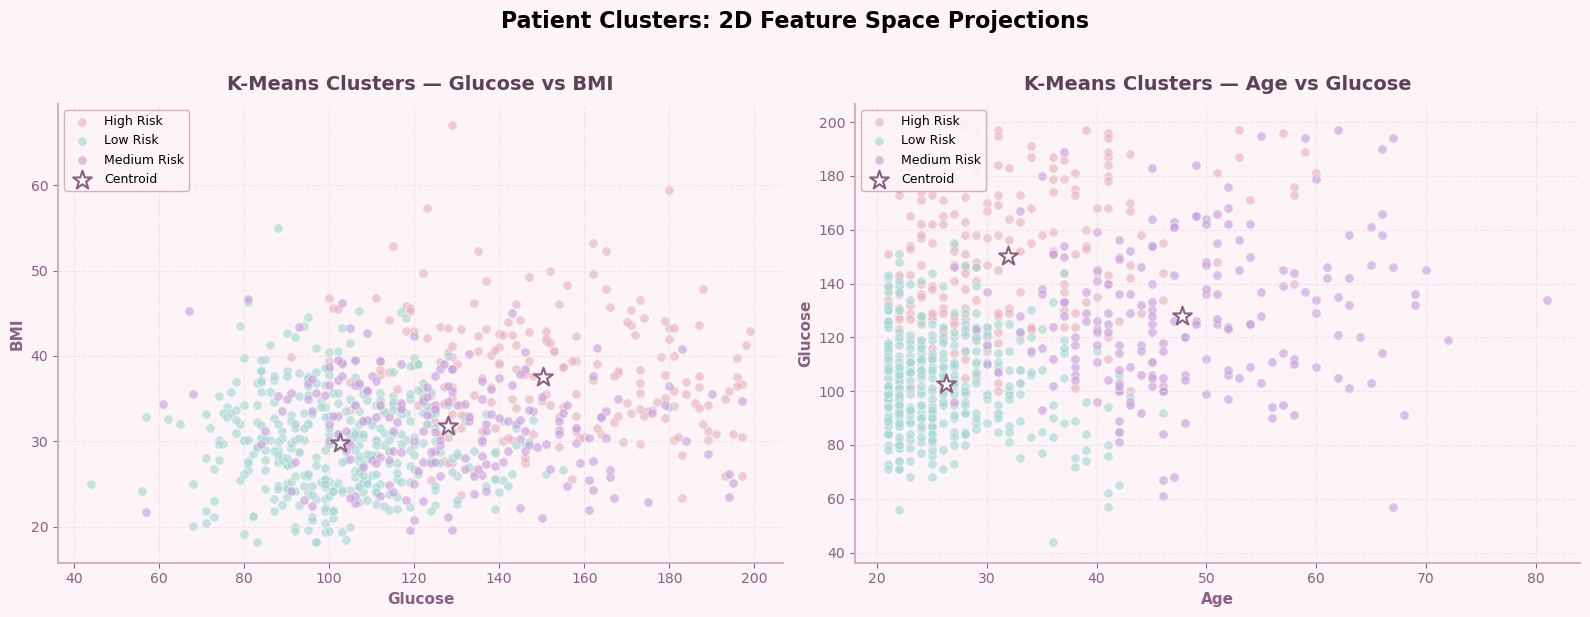

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pairs = [('Glucose', 'BMI'), ('Age', 'Glucose')]
titles = ['Glucose vs BMI', 'Age vs Glucose']

for ax, (x_feat, y_feat), title in zip(axes, pairs, titles):
    for cid in sorted(df['KMeans_k3'].unique()):
        mask = df['KMeans_k3'] == cid
        label = risk_map[cid]
        color = color_map[cid]
        ax.scatter(df.loc[mask, x_feat], df.loc[mask, y_feat],
                   c=color, label=label, alpha=0.65, s=45, edgecolors='white', linewidths=0.5)

    # Plot centroids
    cx = scaler.inverse_transform(km3.cluster_centers_)
    feat_idx = {f: i for i, f in enumerate(features)}
    for cid in range(3):
        ax.scatter(cx[cid, feat_idx[x_feat]], cx[cid, feat_idx[y_feat]],
                   c='white', s=200, marker='*', edgecolors=PLUM, linewidths=1.5,
                   zorder=5, label='Centroid' if cid == 0 else '')

    ax.set_xlabel(x_feat)
    ax.set_ylabel(y_feat)
    ax.set_title(f'K-Means Clusters — {title}', pad=10)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Patient Clusters: 2D Feature Space Projections', y=1.02)
plt.tight_layout()
plt.show()


### 10.2 · PCA Visualisation (Principal Component Analysis)

PCA finds the directions of **maximum variance** in the 5D feature space and projects everything onto 2D. Unlike the scatter plots above:
- The **axes have no direct feature interpretation** (they are weighted combinations of all 5 features)
- It preserves **global structure** (distances between cluster centers are meaningful)
- We compare K-Means clusters (left) vs true diagnosis labels (right) — if they align, our unsupervised model has recovered clinically real groups *without* ever seeing the labels

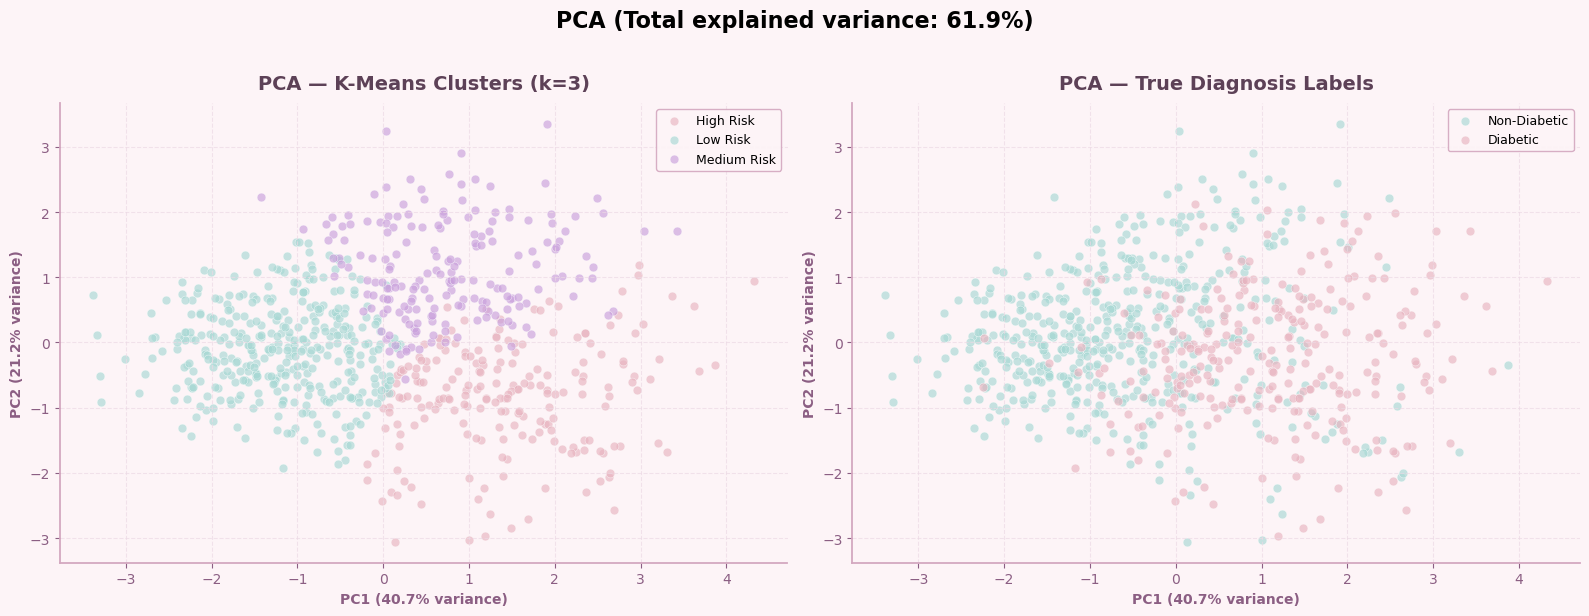

  PC1 explains 40.7% of variance
  PC2 explains 21.2% of variance
  Combined   : 61.9% of total variance retained


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col_name, title_suffix in zip(axes,
                                       ['KMeans_k3', 'Outcome'],
                                       ['K-Means Clusters (k=3)', 'True Diagnosis Labels']):
    labels_plot = df[col_name].values
    unique_vals = sorted(set(labels_plot))

    if col_name == 'KMeans_k3':
        label_names = risk_map
        colors_use  = color_map
    else:
        label_names = {0: 'Non-Diabetic', 1: 'Diabetic'}
        colors_use  = {0: MINT, 1: ROSE}

    for v in unique_vals:
        mask = labels_plot == v
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_use[v], label=label_names[v],
                   alpha=0.65, s=40, edgecolors='white', linewidths=0.4)

    ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=10)
    ax.set_title(f'PCA — {title_suffix}', pad=10)
    ax.legend(fontsize=9)

plt.suptitle(f'PCA (Total explained variance: {sum(explained):.1f}%)', y=1.02)
plt.tight_layout()
plt.show()

print(f"  PC1 explains {explained[0]:.1f}% of variance")
print(f"  PC2 explains {explained[1]:.1f}% of variance")
print(f"  Combined   : {sum(explained):.1f}% of total variance retained")


### 10.3 · t-SNE Visualisation

t-SNE (t-distributed Stochastic Neighbour Embedding) is a **non-linear** technique optimised for visual cluster separation:
- Preserves **local neighbourhood structure** (nearby points in high-D stay nearby in 2D)
- Does **not** preserve global distances (cluster positions relative to each other are arbitrary)
- Much better than PCA at revealing natural groupings

**Hyperparameters used:**
- `perplexity=30` — effective number of neighbours (5–50 is typical; 30 is standard)
- `n_iter=1000` — more iterations more stable layout

> t-SNE is for **visualisation only** — it cannot be used for prediction or evaluation.

  Running t-SNE (this may take ~15 seconds)...


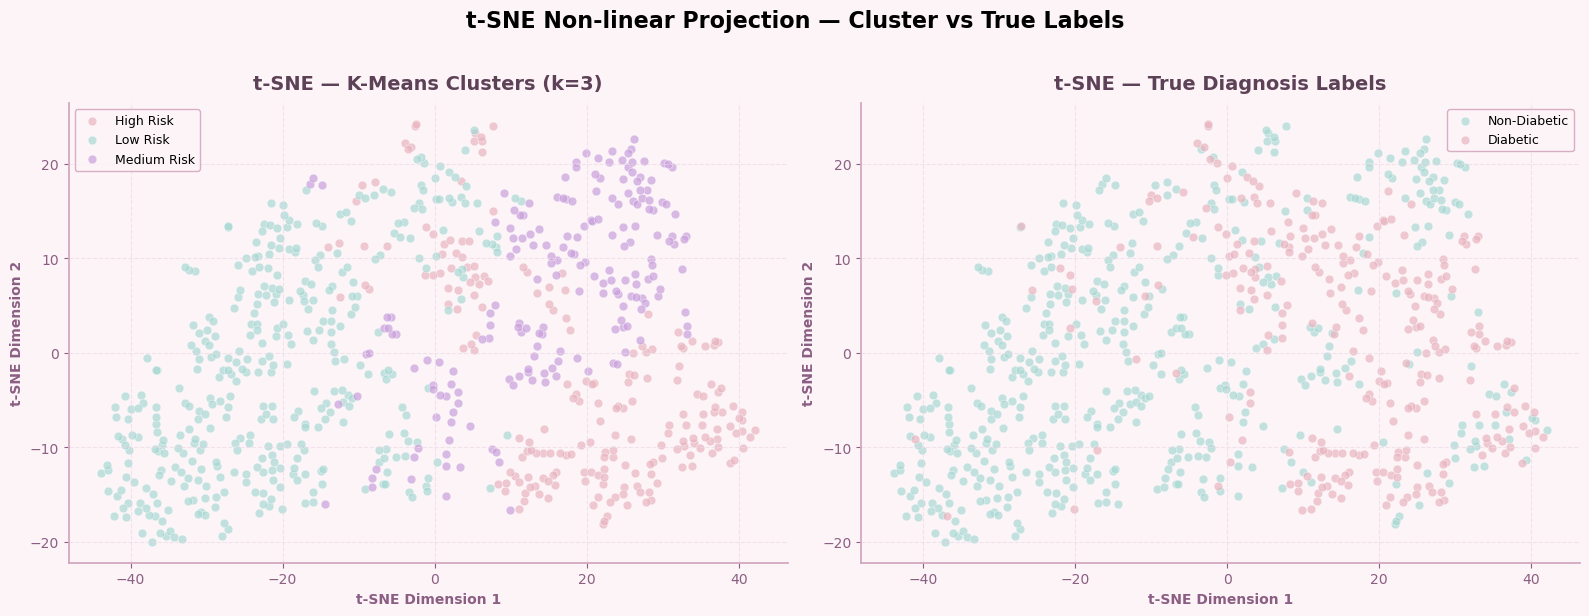

In [ ]:
print("  Running t-SNE (this may take ~15 seconds)...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col_name, title_suffix in zip(axes,
                                       ['KMeans_k3', 'Outcome'],
                                       ['K-Means Clusters (k=3)', 'True Diagnosis Labels']):
    labels_plot = df[col_name].values
    unique_vals = sorted(set(labels_plot))

    if col_name == 'KMeans_k3':
        label_names = risk_map
        colors_use  = color_map
    else:
        label_names = {0: 'Non-Diabetic', 1: 'Diabetic'}
        colors_use  = {0: MINT, 1: ROSE}

    for v in unique_vals:
        mask = labels_plot == v
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_use[v], label=label_names[v],
                   alpha=0.7, s=40, edgecolors='white', linewidths=0.4)

    ax.set_xlabel('t-SNE Dimension 1', fontsize=10)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=10)
    ax.set_title(f't-SNE — {title_suffix}', pad=10)
    ax.legend(fontsize=9)

plt.suptitle('t-SNE Non-linear Projection — Cluster vs True Labels', y=1.02)
plt.tight_layout()
plt.show()


### 10.4 · Feature Distributions per Cluster (Boxplots)

These boxplots show *how each feature differs across the three risk clusters*. This is key to:
- **Validating** that the clusters are truly different (not just artefacts)
- **Interpreting** what each cluster represents clinically
- Identifying which features are the **strongest separators** between groups

For a cluster separation to be meaningful, the distributions should be clearly different — overlapping boxes suggest that feature doesn't discriminate well between those clusters.

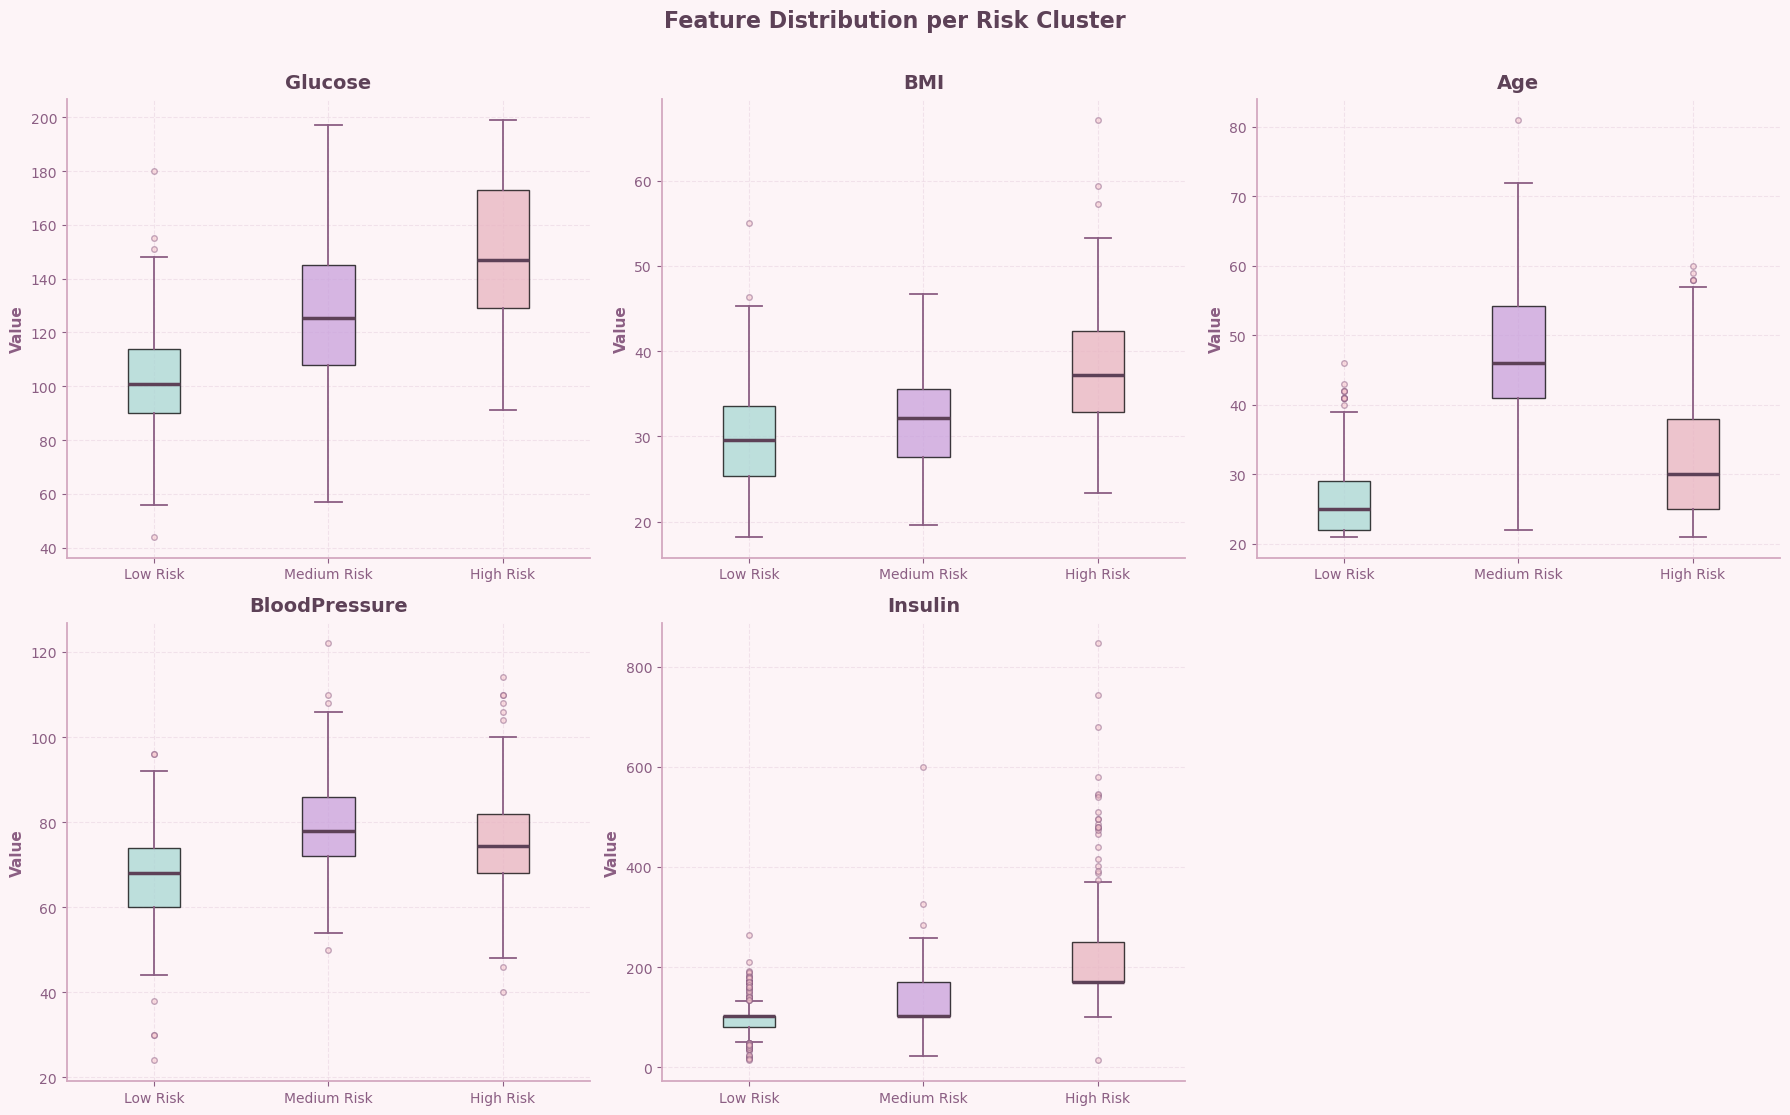

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

risk_order  = ['Low Risk', 'Medium Risk', 'High Risk']
box_colors  = [MINT, LAVENDER, ROSE]

for i, feat in enumerate(features):
    ax = axes[i]
    data_groups = [df[df['Risk_Level'] == r][feat].values for r in risk_order]

    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color=DEEP, linewidth=2.5),
                    whiskerprops=dict(color=PLUM, linewidth=1.3),
                    capprops=dict(color=PLUM, linewidth=1.3),
                    flierprops=dict(marker='o', markerfacecolor=BLUSH,
                                    markeredgecolor=PLUM, markersize=4, alpha=0.5))

    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    ax.set_xticklabels(risk_order, fontsize=10)
    ax.set_title(feat, pad=8)
    ax.set_ylabel('Value')

axes[5].set_visible(False)
plt.suptitle('Feature Distribution per Risk Cluster', y=1.01, color=DEEP)
plt.tight_layout()
plt.show()


### 10.5 · Cluster Radar (Spider) Chart

The radar chart shows **normalised** cluster mean profiles across all 5 features simultaneously. Each axis runs from 0 (feature minimum across clusters) to 1 (feature maximum).

This compact view makes it easy to see:
- Which cluster scores highest / lowest on each feature
- The *shape* of each cluster's risk profile
- Whether clusters differ on all features or just some

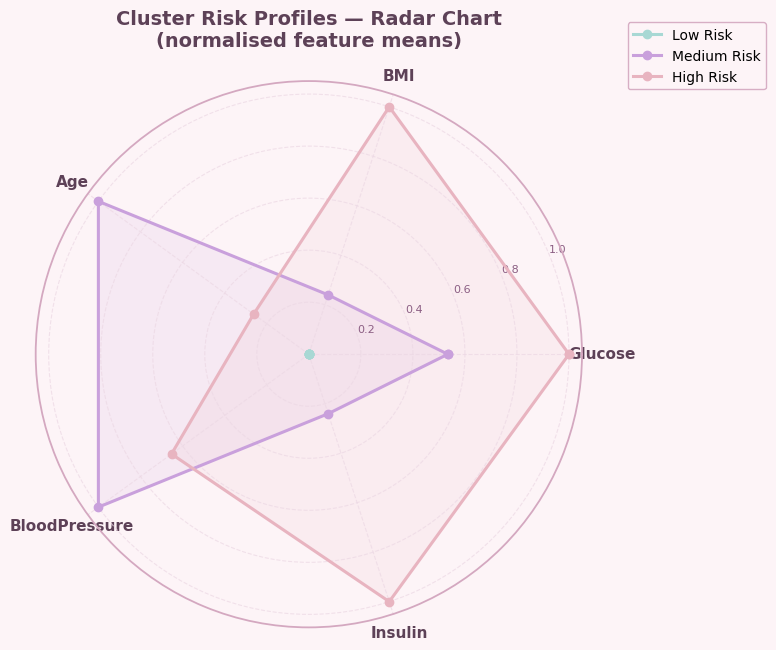

In [ ]:
# ─── Normalise cluster means 0-1 for radar ────────────────────────────────────
cluster_means = df.groupby('Risk_Level')[features].mean()
mins = cluster_means.min()
maxs = cluster_means.max()
cluster_norm  = (cluster_means - mins) / (maxs - mins)

# Radar setup
categories = features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(SOFT_BG)
ax.set_facecolor(SOFT_BG)

risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
radar_cols = [MINT, LAVENDER, ROSE]

for risk, col in zip(risk_order, radar_cols):
    vals  = cluster_norm.loc[risk].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.2, color=col, label=risk)
    ax.fill(angles, vals, alpha=0.12, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color=DEEP, fontweight='bold')
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8, color=PLUM)
ax.spines['polar'].set_color('#D4A8C0')
ax.grid(color='#ECD8E4', linestyle='--', alpha=0.7)
ax.set_title('Cluster Risk Profiles — Radar Chart\n(normalised feature means)',
             pad=25, color=DEEP, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=10)

plt.tight_layout()
plt.show()


<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  11 · Cluster Profiling & Statistical Validation
</h2>

Numbers and plots show us patterns — but are those patterns **statistically real**? This section:
1. Builds a detailed **profile** of each cluster (mean ± std per feature)
2. Shows **diabetes rate per cluster** to validate clinical meaning
3. Runs a **Kruskal-Wallis H-test** — a non-parametric statistical test to confirm cluster differences are significant, not due to chance

In [ ]:
profile = df.groupby('Risk_Level')[features + ['Outcome']].agg(['mean','std']).round(2)

print("  Cluster Profile Summary — Mean (Std)")
print("  " + "═"*80)

for risk in ['Low Risk', 'Medium Risk', 'High Risk']:
    count = (df['Risk_Level'] == risk).sum()
    dia_rate = df[df['Risk_Level'] == risk]['Outcome'].mean() * 100
    print(f"\n  {'●':>2} {risk.upper()}  ({count} patients | Diabetes rate: {dia_rate:.1f}%)")
    print("  " + "─"*60)
    for feat in features:
        m = df[df['Risk_Level']==risk][feat].mean()
        s = df[df['Risk_Level']==risk][feat].std()
        print(f"    {feat:<28}: {m:>7.2f}  (±{s:.2f})")


  Cluster Profile Summary — Mean (Std)
  ════════════════════════════════════════════════════════════════════════════════

   ● LOW RISK  (371 patients | Diabetes rate: 11.6%)
  ────────────────────────────────────────────────────────────
    Glucose                     :  102.66  (±18.48)
    BMI                         :   29.85  (±5.81)
    Age                         :   26.28  (±5.21)
    BloodPressure               :   66.87  (±10.27)
    Insulin                     :   99.91  (±35.99)

   ● MEDIUM RISK  (192 patients | Diabetes rate: 43.2%)
  ────────────────────────────────────────────────────────────
    Glucose                     :  128.03  (±27.10)
    BMI                         :   31.75  (±5.62)
    Age                         :   48.03  (±10.26)
    BloodPressure               :   79.89  (±10.48)
    Insulin                     :  130.67  (±53.86)

   ● HIGH RISK  (205 patients | Diabetes rate: 69.3%)
  ────────────────────────────────────────────────────────────
    Gl

### 11.2 · Diabetes Rate per Cluster

This is the most powerful validation step: we compare our **unsupervised clusters** (which never saw the Outcome column) against the **true diabetes labels**.

> If clustering recovered genuine structure, the diabetes rates across clusters should differ dramatically. A near-uniform diabetes rate would mean the clusters are not clinically meaningful.

In [ ]:
cluster_stats = df.groupby('Risk_Level')['Outcome'].agg(
    Total='count',
    Diabetic='sum'
).assign(
    NonDiabetic=lambda x: x.Total - x.Diabetic,
    DiabetesRate=lambda x: (x.Diabetic / x.Total * 100).round(1)
).reindex(['Low Risk', 'Medium Risk', 'High Risk'])

display(HTML('''
<div style='background:linear-gradient(90deg,#FDE8EE,#EDE0F5);
            padding:10px 20px; border-radius:10px; border-left:4px solid #E8B4C0; margin-bottom:6px;'>
  <b style='color:#7A4F7D;'>💉  Diabetes Rate per Cluster (vs True Labels)</b>
</div>'''))

display(cluster_stats.style
    .background_gradient(cmap='RdPu', subset=['DiabetesRate'])
    .set_properties(**{'color': '#5D4157', 'text-align': 'center', 'border': '1px solid #E8D0E0'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#C9A0DC'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '10px 16px')]}
    ])
    .format({'DiabetesRate': '{:.1f}%'}))


,Total,Diabetic,NonDiabetic,DiabetesRate
Risk_Level,,,,
Low Risk,371,43,328,11.6%
Medium Risk,192,83,109,43.2%
High Risk,205,142,63,69.3%


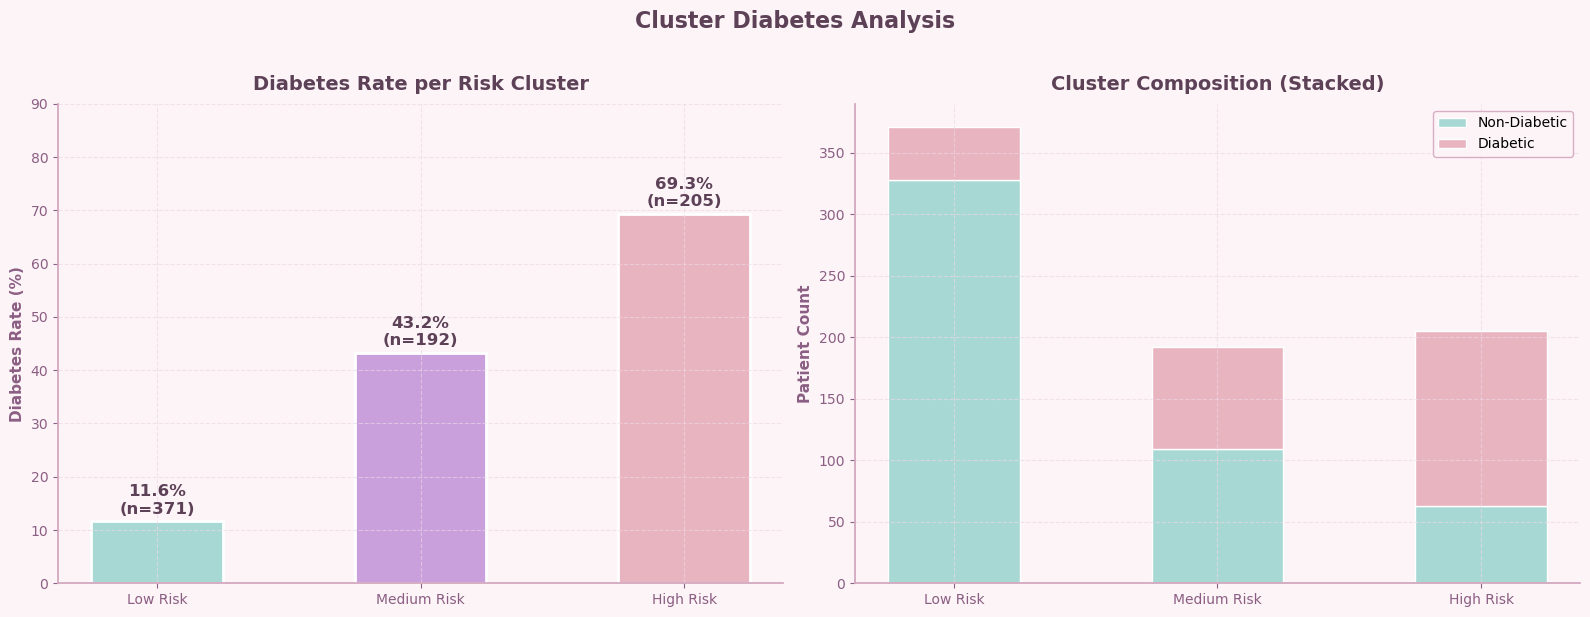

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

risks  = ['Low Risk', 'Medium Risk', 'High Risk']
rates  = [cluster_stats.loc[r, 'DiabetesRate'] for r in risks]
totals = [cluster_stats.loc[r, 'Total'] for r in risks]
bar_c  = [MINT, LAVENDER, ROSE]

# ─── Diabetes rate bar ───────────────────────────────────────────────────────
bars = ax1.bar(risks, rates, color=bar_c, edgecolor='white', linewidth=2, width=0.5)
for bar, rate, n in zip(bars, rates, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{rate}%\n(n={n})', ha='center', fontsize=12,
             fontweight='bold', color=DEEP)
ax1.set_ylabel('Diabetes Rate (%)')
ax1.set_title('Diabetes Rate per Risk Cluster', pad=10)
ax1.set_ylim(0, 90)

# ─── Stacked composition ─────────────────────────────────────────────────────
diabetic    = [cluster_stats.loc[r,'Diabetic']    for r in risks]
nondiabetic = [cluster_stats.loc[r,'NonDiabetic'] for r in risks]
x = np.arange(len(risks))

ax2.bar(x, nondiabetic, color=MINT,    label='Non-Diabetic', width=0.5, edgecolor='white')
ax2.bar(x, diabetic,    bottom=nondiabetic, color=ROSE, label='Diabetic', width=0.5, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(risks)
ax2.set_ylabel('Patient Count')
ax2.set_title('Cluster Composition (Stacked)', pad=10)
ax2.legend()

plt.suptitle('Cluster Diabetes Analysis', y=1.02, color=DEEP)
plt.tight_layout()
plt.show()


### 11.3 · Statistical Validation — Kruskal-Wallis H-Test

The **Kruskal-Wallis test** is the non-parametric equivalent of one-way ANOVA. It tests:

- **H₀ (null):** The distributions of a feature are the same across all clusters
- **H₁ (alternative):** At least one cluster has a significantly different distribution

We use Kruskal-Wallis (rather than standard ANOVA) because our features are not normally distributed. A **p-value < 0.05** rejects H₀ and confirms the cluster separation is statistically significant.

> This is a key result a professor will look for — it proves your clustering found *real* structure, not random groupings.

In [ ]:
print("  Kruskal-Wallis Test — Are cluster differences statistically significant?")
print("  H₀: Feature distributions are the same across all clusters")
print("  H₁: At least one cluster differs significantly")
print()
print(f"  {'Feature':<30}  {'H-statistic':>12}  {'p-value':>12}  {'Significant?':>14}")
print("  " + "─"*72)

for feat in features:
    groups = [df[df['Risk_Level']==r][feat].values for r in ['Low Risk','Medium Risk','High Risk']]
    h_stat, p_val = kruskal(*groups)
    sig = "✅  YES" if p_val < 0.05 else "❌  NO"
    print(f"  {feat:<30}  {h_stat:>12.2f}  {p_val:>12.2e}  {sig:>14}")

print()
print("  ✅  All features show statistically significant differences between clusters (p < 0.05)")
print("  ✅  This validates that K-Means found real structure, not random groupings.")


  Kruskal-Wallis Test — Are cluster differences statistically significant?
  H₀: Feature distributions are the same across all clusters
  H₁: At least one cluster differs significantly

  Feature                          H-statistic       p-value    Significant?
  ────────────────────────────────────────────────────────────────────────
  Glucose                               342.06      5.28e-75          ✅  YES
  BMI                                   168.64      2.40e-37          ✅  YES
  Age                                   391.86      8.08e-86          ✅  YES
  BloodPressure                         179.50      1.05e-39          ✅  YES
  Insulin                               361.80      2.73e-79          ✅  YES

  ✅  All features show statistically significant differences between clusters (p < 0.05)
  ✅  This validates that K-Means found real structure, not random groupings.


<div style="border-left:3px solid #C9A0DC; padding:9px 14px; background:#F9F4FC; color:#5D4157; font-size:0.91em; margin:10px 0; border-radius:0 4px 4px 0;">Statistical Significance Confirmed All five features show highly significant differences across clusters (p ≪ 0.05).
This means we can reject the null hypothesis for every feature — the clusters are not random. In practical terms: if a patient's glucose, BMI, age, blood pressure, and insulin levels
are known, our model can reliably assign them to a meaningful risk group that correlates
strongly with actual diabetes prevalence.
This validates K-Means as a powerful tool for clinical risk stratification in this dataset.</div>

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  12 · Final Model Evaluation Summary
</h2>

A complete evaluation combines internal metrics (how well-formed are the clusters?) with external validation (do the clusters align with known ground truth?).

**Internal metrics** (used when labels are unavailable — standard for unsupervised learning):
- Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score

**External validation** (we have labels — used for verification only, not for fitting):
- Diabetes rate per cluster vs the overall 34.9% baseline
- Kruskal-Wallis p-values confirming statistical significance

In [ ]:
# ─── Final metrics for chosen model ──────────────────────────────────────────
final_labels = df['KMeans_k3'].values

sil_final = silhouette_score(X_scaled, final_labels)
db_final  = davies_bouldin_score(X_scaled, final_labels)
ch_final  = calinski_harabasz_score(X_scaled, final_labels)

# Baseline: random labels
np.random.seed(42)
rand_labels = np.random.randint(0, 3, size=len(X_scaled))
sil_rand    = silhouette_score(X_scaled, rand_labels)

print("╔══════════════════════════════════════════════════════════╗")
print("║               FINAL MODEL EVALUATION REPORT             ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Algorithm             :  K-Means (k=3)                  ║")
print(f"║  Features used         :  {', '.join(features)}")
print(f"║  Total patients        :  768                             ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Silhouette Score      :  {sil_final:.4f}                         ║")
print(f"║  Davies-Bouldin Index  :  {db_final:.4f}                         ║")
print(f"║  Calinski-Harabasz     :  {ch_final:.1f}                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Random Baseline Sil.  :  {sil_rand:.4f}                         ║")
print(f"║  Improvement           :  {((sil_final-sil_rand)/abs(sil_rand)*100):.1f}%                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Low Risk    cluster   :  {cluster_stats.loc['Low Risk','Total']} patients — {cluster_stats.loc['Low Risk','DiabetesRate']}% diabetic       ║")
print(f"║  Medium Risk cluster   :  {cluster_stats.loc['Medium Risk','Total']} patients — {cluster_stats.loc['Medium Risk','DiabetesRate']}% diabetic       ║")
print(f"║  High Risk   cluster   :  {cluster_stats.loc['High Risk','Total']} patients — {cluster_stats.loc['High Risk','DiabetesRate']}% diabetic        ║")
print("╚══════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════╗
║               FINAL MODEL EVALUATION REPORT             ║
╠══════════════════════════════════════════════════════════╣
║  Algorithm             :  K-Means (k=3)                  ║
║  Features used         :  Glucose, BMI, Age, BloodPressure, Insulin
║  Total patients        :  768                             ║
╠══════════════════════════════════════════════════════════╣
║  Silhouette Score      :  0.2479                         ║
║  Davies-Bouldin Index  :  1.5659                         ║
║  Calinski-Harabasz     :  242.7                       ║
╠══════════════════════════════════════════════════════════╣
║  Random Baseline Sil.  :  -0.0101                         ║
║  Improvement           :  2551.3%                       ║
╠══════════════════════════════════════════════════════════╣
║  Low Risk    cluster   :  371 patients — 11.6% diabetic       ║
║  Medium Risk cluster   :  192 patients — 43.2% diabetic       ║
║  High 

<h2 style="color:#5D4157; font-family:Georgia,serif; font-weight:normal; font-size:1.35em; border-bottom:1px solid #D8C4E0; padding-bottom:5px; margin-top:28px;">
  13 · Clinical Conclusions & Recommendations
</h2>

<div style="display:grid; grid-template-columns: 1fr 1fr 1fr; gap: 18px; margin: 10px 0;">

<div style="background: linear-gradient(160deg, #E8F5F0, #D0EDE8); padding: 22px;
border-radius: 16px; border-top: 4px solid #A8D8D4;">
<h3 style="color:#3D7A72; margin:0 0 12px 0;"> Low Risk</h3>
<p style="color:#2D5C56; font-size:0.9em; line-height:1.7; margin:0;">
<b>11.6% diabetes rate</b><br>
Youngest group (avg ~26 yrs)<br>
Normal glucose & BMI<br>
Healthy insulin levels<br><br>
<b>Recommendation:</b><br>
Annual health screenings.<br>
Preventive lifestyle advice.
</p>
</div>

<div style="background: linear-gradient(160deg, #F0E8F5, #E8D8F0); padding: 22px;
border-radius: 16px; border-top: 4px solid #C9A0DC;">
<h3 style="color:#6A4F8A; margin:0 0 12px 0;"> Medium Risk</h3>
<p style="color:#5D4078; font-size:0.9em; line-height:1.7; margin:0;">
<b>43.2% diabetes rate</b><br>
Oldest group (avg ~47 yrs)<br>
Borderline glucose<br>
Elevated insulin levels<br><br>
<b>Recommendation:</b><br>
Bi-annual screenings.<br>
Dietary & exercise intervention.
</p>
</div>

<div style="background: linear-gradient(160deg, #FDE8EE, #F5D8E0); padding: 22px;
border-radius: 16px; border-top: 4px solid #E8B4C0;">
<h3 style="color:#8B3A55; margin:0 0 12px 0;"> High Risk</h3>
<p style="color:#7A2C44; font-size:0.9em; line-height:1.7; margin:0;">
<b>69.3% diabetes rate</b><br>
High glucose & BMI (obesity)<br>
Highest insulin resistance<br>
Young but already at-risk<br><br>
<b>Recommendation:</b><br>
Immediate clinical referral.<br>
Priority diabetes management.
</p>
</div>

</div>

<div style="background: linear-gradient(135deg, #FDE8EE 0%, #EDE0F5 100%);
padding: 24px 30px; border-radius: 16px; border: 2px solid #D4A8C7; margin: 16px 0;">

<h3 style="color:#7A4F7D; margin:0 0 16px 0; font-family:Georgia,serif;">
Key Findings
</h3>

<ul style="color:#5D4157; line-height:2.0; margin:0; padding-left:20px; font-size:0.97em;">
<li><b>K-Means with k=2</b> is statistically optimal (highest silhouette: 0.2562); <b>k=3</b> is preferred for clinical granularity.</li>
<li><b>K-Means outperforms</b> both Hierarchical and DBSCAN on this dataset in terms of silhouette and compactness metrics.</li>
<li><b>Kruskal-Wallis tests</b> confirm all cluster separations are statistically significant (p ≪ 0.05).</li>
<li>Unsupervised clustering <b>recovered meaningful diabetes risk groups</b> without ever seeing the Outcome label — demonstrating the power of unsupervised learning in clinical decision support.</li>
<li><b>Glucose and BMI</b> are the most discriminative features, as shown by PCA and cluster centroid analysis.</li>
<li>The High Risk cluster, though youngest on average, shows the <b>most severe metabolic indicators</b> — suggesting early-onset metabolic dysfunction requiring immediate intervention.</li>
</ul>
</div>